# General stuff

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import pandas as pd
import random
import seaborn as sns
from torch import nn

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


from belearn.viz.viz import Viz
from belearn.dataset.dataset import BE_Dataset
from belearn.functions.sho import SHO_nn

from autophyslearn.spectroscopic.nn import Multiscale1DFitter, Model
from autophyslearn.postprocessing.complex import ComplexPostProcessor

from m3util.ml.rand import set_seeds
from m3util.viz.style import set_style
from m3util.viz.printing import printer
from m3util.viz.layout import inset_connector, add_box, imagemap, FigDimConverter, subfigures
from m3util.viz.text import set_sci_notation_label, labelfigs, bring_text_to_front, number_to_letters


printing = printer(basepath = './Figures/')


set_style("printing")
set_seeds(seed=42)

%matplotlib inline

printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42


2025-05-19 10:46:29.146389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747665989.162586 1892653 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747665989.167637 1892653 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-19 10:46:29.185220: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow seed was set to 42


In [4]:
# Specify the filename and the path to save the file
filename = "data_raw.h5"
save_path = "./Data"

data_path = save_path + "/" + filename



# instantiate the dataset object7
dataset = BE_Dataset(data_path)

#dataset = BE_Dataset(data_path)


# print the contents of the file
dataset.print_be_tree

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

In [5]:
# instantiates the visualization object
BE_viz = Viz(dataset, printing, verbose=True)
BE_viz.SHO_preprocessing()
#BE_viz.SHO_Scaler()

Accessing data at: Raw_Data-SHO_Fit_000/Fit


# Figure 1

pixel:  3174
voltagestep:  348


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


./Figures/Figure_2_raw_be_experiment_test.png
./Figures/Figure_2_raw_be_experiment_test.svg


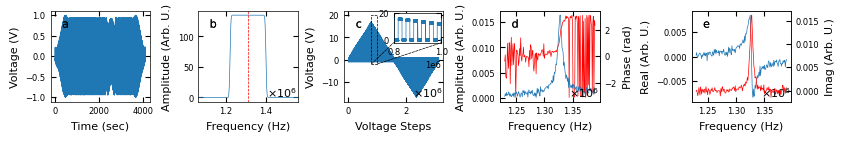

In [4]:
fig = BE_viz.raw_be(dataset, filename="Figure_2_raw_be_experiment_test")

In [5]:
axes = fig.axes

In [6]:
axes

[<Axes: xlabel='Time (sec)', ylabel='Voltage (V)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Amplitude (Arb. U.)'>,
 <Axes: xlabel='Voltage Steps', ylabel='Voltage (V)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Amplitude (Arb. U.)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Real (Arb. U.)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Phase (rad)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Imag (Arb. U.)'>]

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


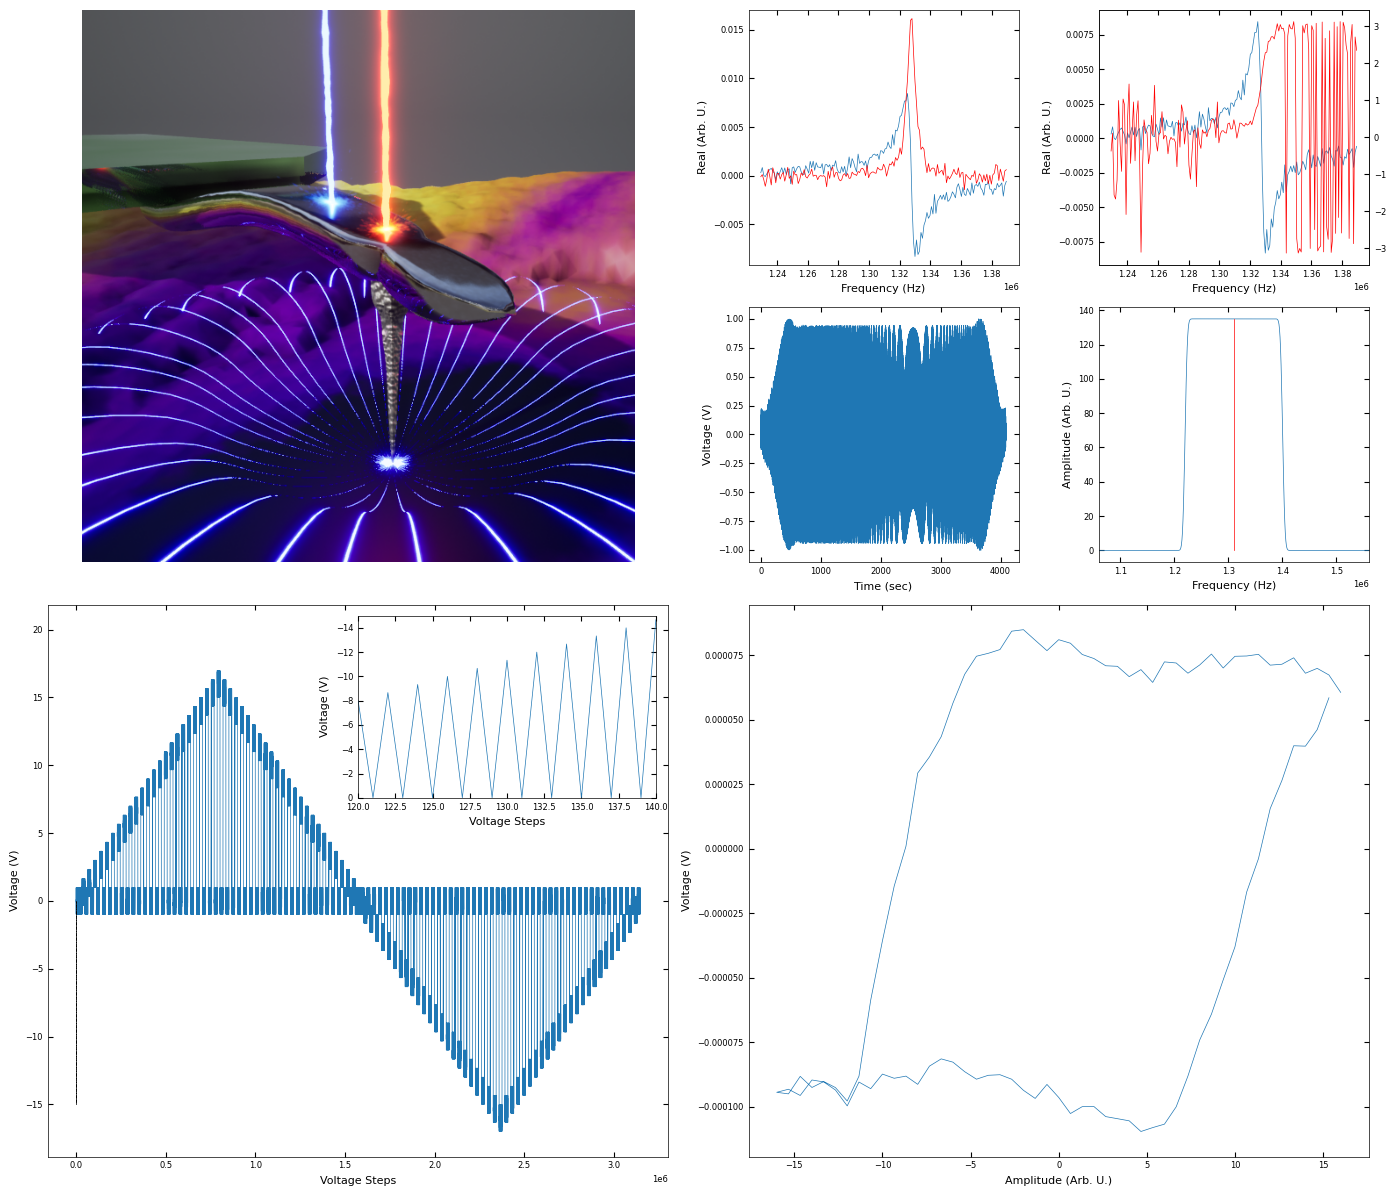

In [7]:
def copy_axes_properties(source_ax, target_ax, secondary_ax=None, type_ax=None):
    """Copy properties and data from source_ax to target_ax."""
    target_ax.set_xlabel(source_ax.get_xlabel())
    target_ax.set_ylabel(source_ax.get_ylabel())
    target_ax.set_xlim(source_ax.get_xlim())
    target_ax.set_ylim(source_ax.get_ylim())
        
    for line in source_ax.get_lines():
        target_ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color())
        
    if secondary_ax != None:
        if type_ax == 'twin':
            ax_twin = target_ax.twinx()
            for line in secondary_ax.get_lines():
                ax_twin.plot(line.get_xdata(), line.get_ydata(), color=line.get_color())
        elif type_ax == 'same':
            for line in secondary_ax.get_lines():
                target_ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color())
                
                max_x_lim = max(source_ax.get_xlim()[1], secondary_ax.get_xlim()[1])
                min_x_lim = min(source_ax.get_xlim()[0], secondary_ax.get_xlim()[0])
                max_y_lim = max(source_ax.get_ylim()[1], secondary_ax.get_ylim()[1])
                min_y_lim = min(source_ax.get_ylim()[0], secondary_ax.get_ylim()[0])
                target_ax.set_xlim((min_x_lim, max_x_lim))
                target_ax.set_ylim((min_y_lim, max_y_lim))
        else:
            ax_new = target_ax.inset_axes([0.5, 0.65, 0.48, 0.33])
            x_start = 120
            x_end = 140
            ax_new.plot(BE_viz.hysteresis_waveform)
            ax_new.set_xlim(x_start, x_end)
            ax_new.set_ylim(0, -15)

            # drows the inset connector
            inset_connector(
                source_ax,
                target_ax,
                ax_new,
                [(x_start, 0), (x_end, 0)],
                [(x_start, 0), (x_end, 0)],
                color="k",
                linestyle="--",
                linewidth=0.5,
            )

            # adds a box on the figure
            add_box(
                target_ax,
                (x_start, 0, x_end, -15),
                edgecolor="k",
                linestyle="--",
                facecolor="none",
                linewidth=0.5,
                zorder=10,
            )
            ax_new.set_xlabel("Voltage Steps")
            ax_new.set_ylabel("Voltage (V)")

# Create a figure
fig = plt.figure(figsize=(14, 12))

# Define the GridSpec layout
gs = GridSpec(4, 4, figure=fig)

order = [['AFM'], [1], [0], [4, 'same', 6], [4, 'twin', 5], [2, 'inset', 3], ['hysteresis_loop']]

# List of axes indices in GridSpec for each subplot
subplot_specs = [(0, 2, 0, 2), # a (3D AFM)
                 (1, 2, 3, 4), # b (resonance frequency)
                 (1, 2, 2, 3), # c (waveform)
                 (0, 1, 2, 3), # d (real/imag)
                 (0, 1, 3, 4), # e (amp/phase)
                 (2, 4, 0, 2), # f (triangular waveform)
                 (2, 4, 2, 4)] # g (hysteresis)

# Create and set up subplots
for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
    ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])
    if i < len(axes):
        idx = order[i]
        if idx[0] == 'AFM':
            image_path = "./assets/AFM_field.png"
            img = mpimg.imread(image_path)
            ax.imshow(img)
            ax.axis('off')  # Turn off axis for image subplot
        elif idx[0] == 'hysteresis_loop':
            raw_hysteresis_loop, voltage = BE_viz.get_hysteresis(
                                loop_interpolated=True, plotting_values=True)
            row = random.randint(0, 59)
            col = random.randint(0, 59)
            cycle = random.randint(0, 3)
            ax.plot(voltage.squeeze()*-1,
                       raw_hysteresis_loop[row, col, cycle, :].squeeze())
            ax.set_xlabel("Amplitude (Arb. U.)")
            ax.set_ylabel("Voltage (V)")
        elif len(idx) == 1:
            copy_axes_properties(axes[idx[0]], ax)
        else:
            copy_axes_properties(axes[idx[0]], ax, axes[idx[2]], idx[1])
            

# Adjust the spacing between the plots as needed
plt.tight_layout()

# Show the layout
plt.show()

# Figure 2 is a diagram of the neural network model structures and is not reproduced in code

# Figure 3

In [2]:
def SHO_fit_func_nn(params,
                    wvec_freq,
                    device='cpu'):
    """_summary_

    Returns:
        _type_: _description_
    """

    Amp = params[:, 0].type(torch.complex128)
    w_0 = params[:, 1].type(torch.complex128)
    Q = params[:, 2].type(torch.complex128)
    phi = params[:, 3].type(torch.complex128)
    wvec_freq = torch.tensor(wvec_freq)

    Amp = torch.unsqueeze(Amp, 1)
    w_0 = torch.unsqueeze(w_0, 1)
    phi = torch.unsqueeze(phi, 1)
    Q = torch.unsqueeze(Q, 1)

    wvec_freq = wvec_freq.to(device)

    numer = Amp * torch.exp((1.j) * phi) * torch.square(w_0)
    den_1 = torch.square(wvec_freq)
    den_2 = (1.j) * wvec_freq.to(device) * w_0 / Q
    den_3 = torch.square(w_0)

    den = den_1 - den_2 - den_3

    func = numer / den

    return func

In [6]:
LSQF_ = {'resampled': True,
                'raw_format': 'complex',
                'fitter': 'LSQF',
                'scaled': False,
                'output_shape': 'index',
                'measurement_state': 'all',
                'resampled_bins': 165,
                'LSQF_phase_shift': 0, #1.5707963267948966,
                'NN_phase_shift': None,
                'noise': 0}

LSQF_Params = BE_viz.SHO_fit_results(state = LSQF_)

In [7]:
# this isn't needed until later but it's here because this needs to be called before scaled is set to True
BE_viz.loop_fit_preprocessing()

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


In [8]:
set_seeds(seed=42)
device = torch.device("cuda:0")

postprocessor = ComplexPostProcessor(BE_viz, device=device)

model_ = Multiscale1DFitter(SHO_fit_func_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor)

# instantiate the model
model = Model(model_, BE_viz, training=False, model_basename="SHO_Fitter_original_data")

model.load(
    #"./Trained Models/SHO Fitter/SHO_Fitter_original_data_noise_0_model_optimizer_Adam_epoch_4_train_loss_0.03404734210730735.pth"
    "./Trained Models/SHO Fitter/2024-09-23_14-36-21_nn_benchmarks_noise/SHO_Fitter_model_optimizer_Adam_epoch_4_train_loss_0.040321211942850994.pth"
)


Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42
Using GPU NVIDIA GeForce RTX 3090


/home/julian/AutoPhysLearn/src/autophyslearn/spectroscopic/nn.py:780: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path,map_loca

In [20]:

# model.load_state_dict(torch.load("./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_599_train_loss_0.005903387442231178.pth"))

X_data, Y_data = BE_viz.get_nn_data()

# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = model.predict(X_data)


(1382400, 4)
(1382400, 4)
./Figures/Figure_15_NN_Switching_Maps_test2.png
./Figures/Figure_15_NN_Switching_Maps_test2.svg


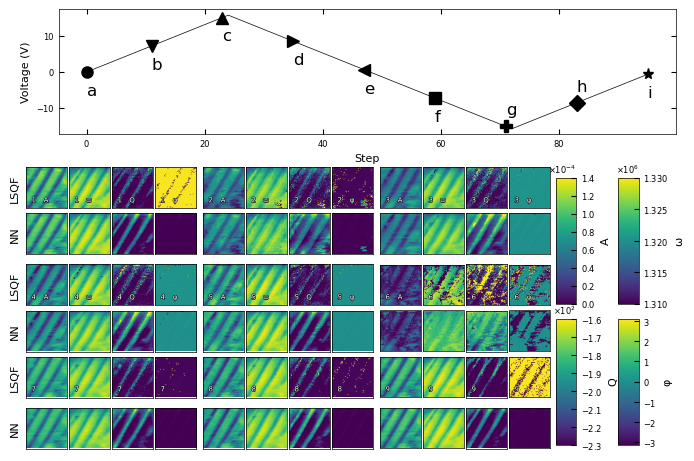

In [9]:
fig = BE_viz.SHO_switching_maps_test([LSQF_Params, parm],labels = ["LSQF", "NN"], filename="Figure_15_NN_Switching_Maps_test2")



(1382400, 4)
(1382400, 4)


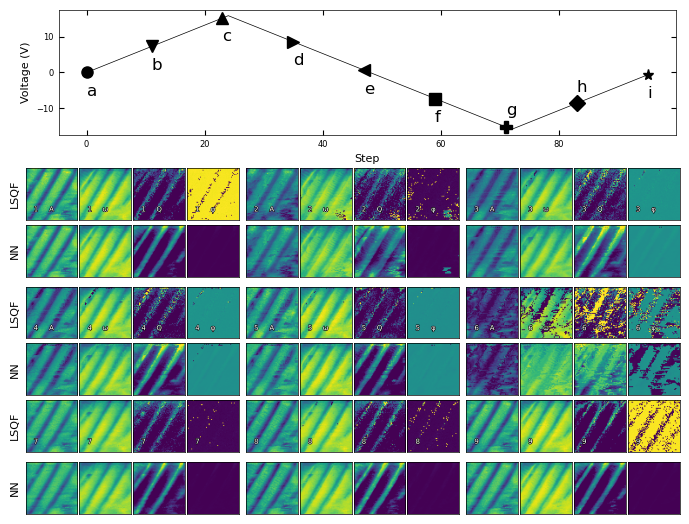

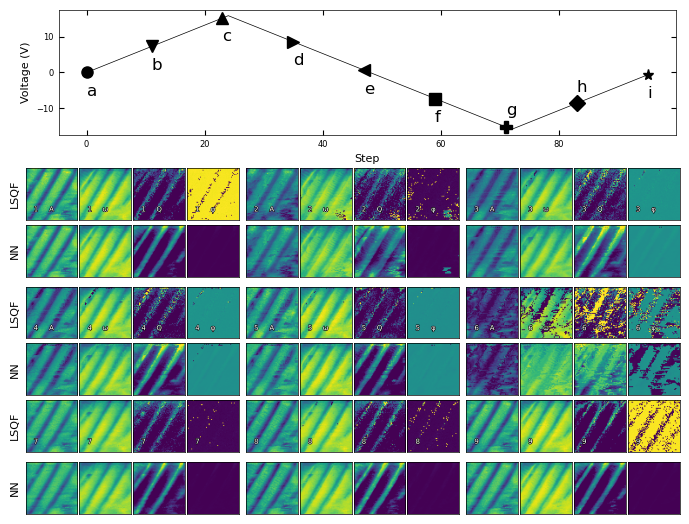

In [98]:
BE_viz.SHO_switching_maps_test([LSQF_Params, parm],labels = ["LSQF", "NN"], filename=None, colorbars = False)


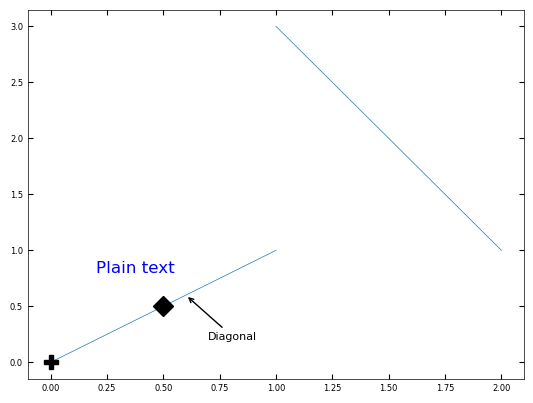

In [39]:
import matplotlib.pyplot as plt
import numpy as np

def create_my_plot():
    """
    Creates a figure with multiple subplots and returns the axes.
    This function does NOT display the figure.
    
    Returns:
        fig_internal (Figure): The internal figure (should be closed after copying)
        axarr (list of Axes): List of subplot axes
    """
    fig_internal, axarr = plt.subplots(1, 2, figsize=(8, 4))

    # Fill both axes
    axarr[0].plot([0, 1], [0, 1], label='y = x')
    axarr[0].set_title('Line')
    axarr[0].plot(0.5,0.5,"D", color="k", markersize=10)
    axarr[0].plot(0,0,"P", color="k", markersize=10)

    axarr[0].set_xlabel('X')
    axarr[0].set_ylabel('Y')
    axarr[0].legend()
    axarr[0].annotate('Diagonal', xy=(0.6, 0.6), xytext=(0.7, 0.2),
                      arrowprops=dict(arrowstyle='->'))
    axarr[0].text(0.2, 0.8, "Plain text", fontsize=12, color="blue")


    axarr[1].plot([1, 2], [3, 1])
    axarr[1].set_title('Another Plot')

    return fig_internal, axarr

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import AxesImage

def copy_axis_to(source_ax, target_ax):
    """
    Efficiently copies the full content of one or multiple source axes into a single target axis.
    Preserves imshow placement via extent. Skips titles and legends.
    """
    if isinstance(source_ax, (list, np.ndarray)):
        all_axes = np.ravel(source_ax)
    else:
        all_axes = [source_ax]

    for i, ax in enumerate(all_axes):
        # ---- Copy imshow images with preserved spatial position ----
        for artist in ax.get_images():
            if isinstance(artist, AxesImage):
                target_ax.imshow(
                    artist.get_array(),
                    extent=artist.get_extent(),
                    cmap=artist.get_cmap(),
                    interpolation=artist.get_interpolation(),
                    vmin=artist.get_clim()[0],
                    vmax=artist.get_clim()[1],
                    origin=artist.origin,
                    alpha=artist.get_alpha()
                )

        # ---- Copy lines and markers (e.g., plot/plot marker) ----
        for line in ax.get_lines():
            target_ax.plot(
                line.get_xdata(),
                line.get_ydata(),
                linestyle=line.get_linestyle(),
                marker=line.get_marker(),
                color=line.get_color(),
                label=line.get_label(),
                markersize=line.get_markersize(),
                linewidth=line.get_linewidth()
            )

        # ---- Copy text and annotations ----
        for txt in ax.texts:
            if isinstance(txt, plt.Annotation):
                target_ax.annotate(
                    text=txt.get_text(),
                    xy=txt.xy,
                    xytext=txt.get_position(),
                    arrowprops=txt.arrowprops if hasattr(txt, 'arrowprops') else None,
                    fontsize=txt.get_fontsize(),
                    color=txt.get_color()
                )
            else:
                target_ax.text(
                    x=txt.get_position()[0],
                    y=txt.get_position()[1],
                    s=txt.get_text(),
                    fontsize=txt.get_fontsize(),
                    color=txt.get_color(),
                    ha=txt.get_ha(),
                    va=txt.get_va(),
                    rotation=txt.get_rotation()
                )

        # ---- Copy patches ----
        for j, patch in enumerate(ax.patches):
            try:
                target_ax.add_patch(patch)
            except Exception:
                raise Exception(
                    f"******* \n Error copying patch {j} in axis {i} \n patch: \n {patch} \n *******"
                )

# 1. Create internal plots
fig_internal, axarr = create_my_plot()

# 2. Choose which axis to copy
selected_ax = axarr  # or axarr[1]

# 3. Create a new figure and copy into it
fig_new, ax_new = plt.subplots()
copy_axis_to(selected_ax, ax_new)

# 4. Close the internal figure
plt.close(fig_internal)

# 5. Show the result
plt.show()


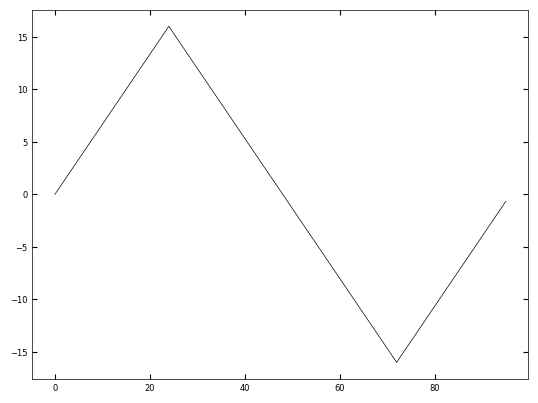

In [33]:
plt.plot(fig.axes[0].get_lines()[0].get_xdata(), fig.axes[0].get_lines()[0].get_ydata(), "k")


In [8]:
axes = fig.axes

./Figures/Figure_16_Violin_2.png
./Figures/Figure_16_Violin_2.svg


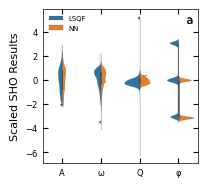

In [13]:
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}


#fig = BE_viz.violin_plot_comparison(true_state, model, X_data, filename="Figure_16_Violin") 
fig = BE_viz.violin_plot_comparison_SHO(true_state, model, X_data, filename="Figure_16_Violin_2",figlabel = 'a', ax=None) 

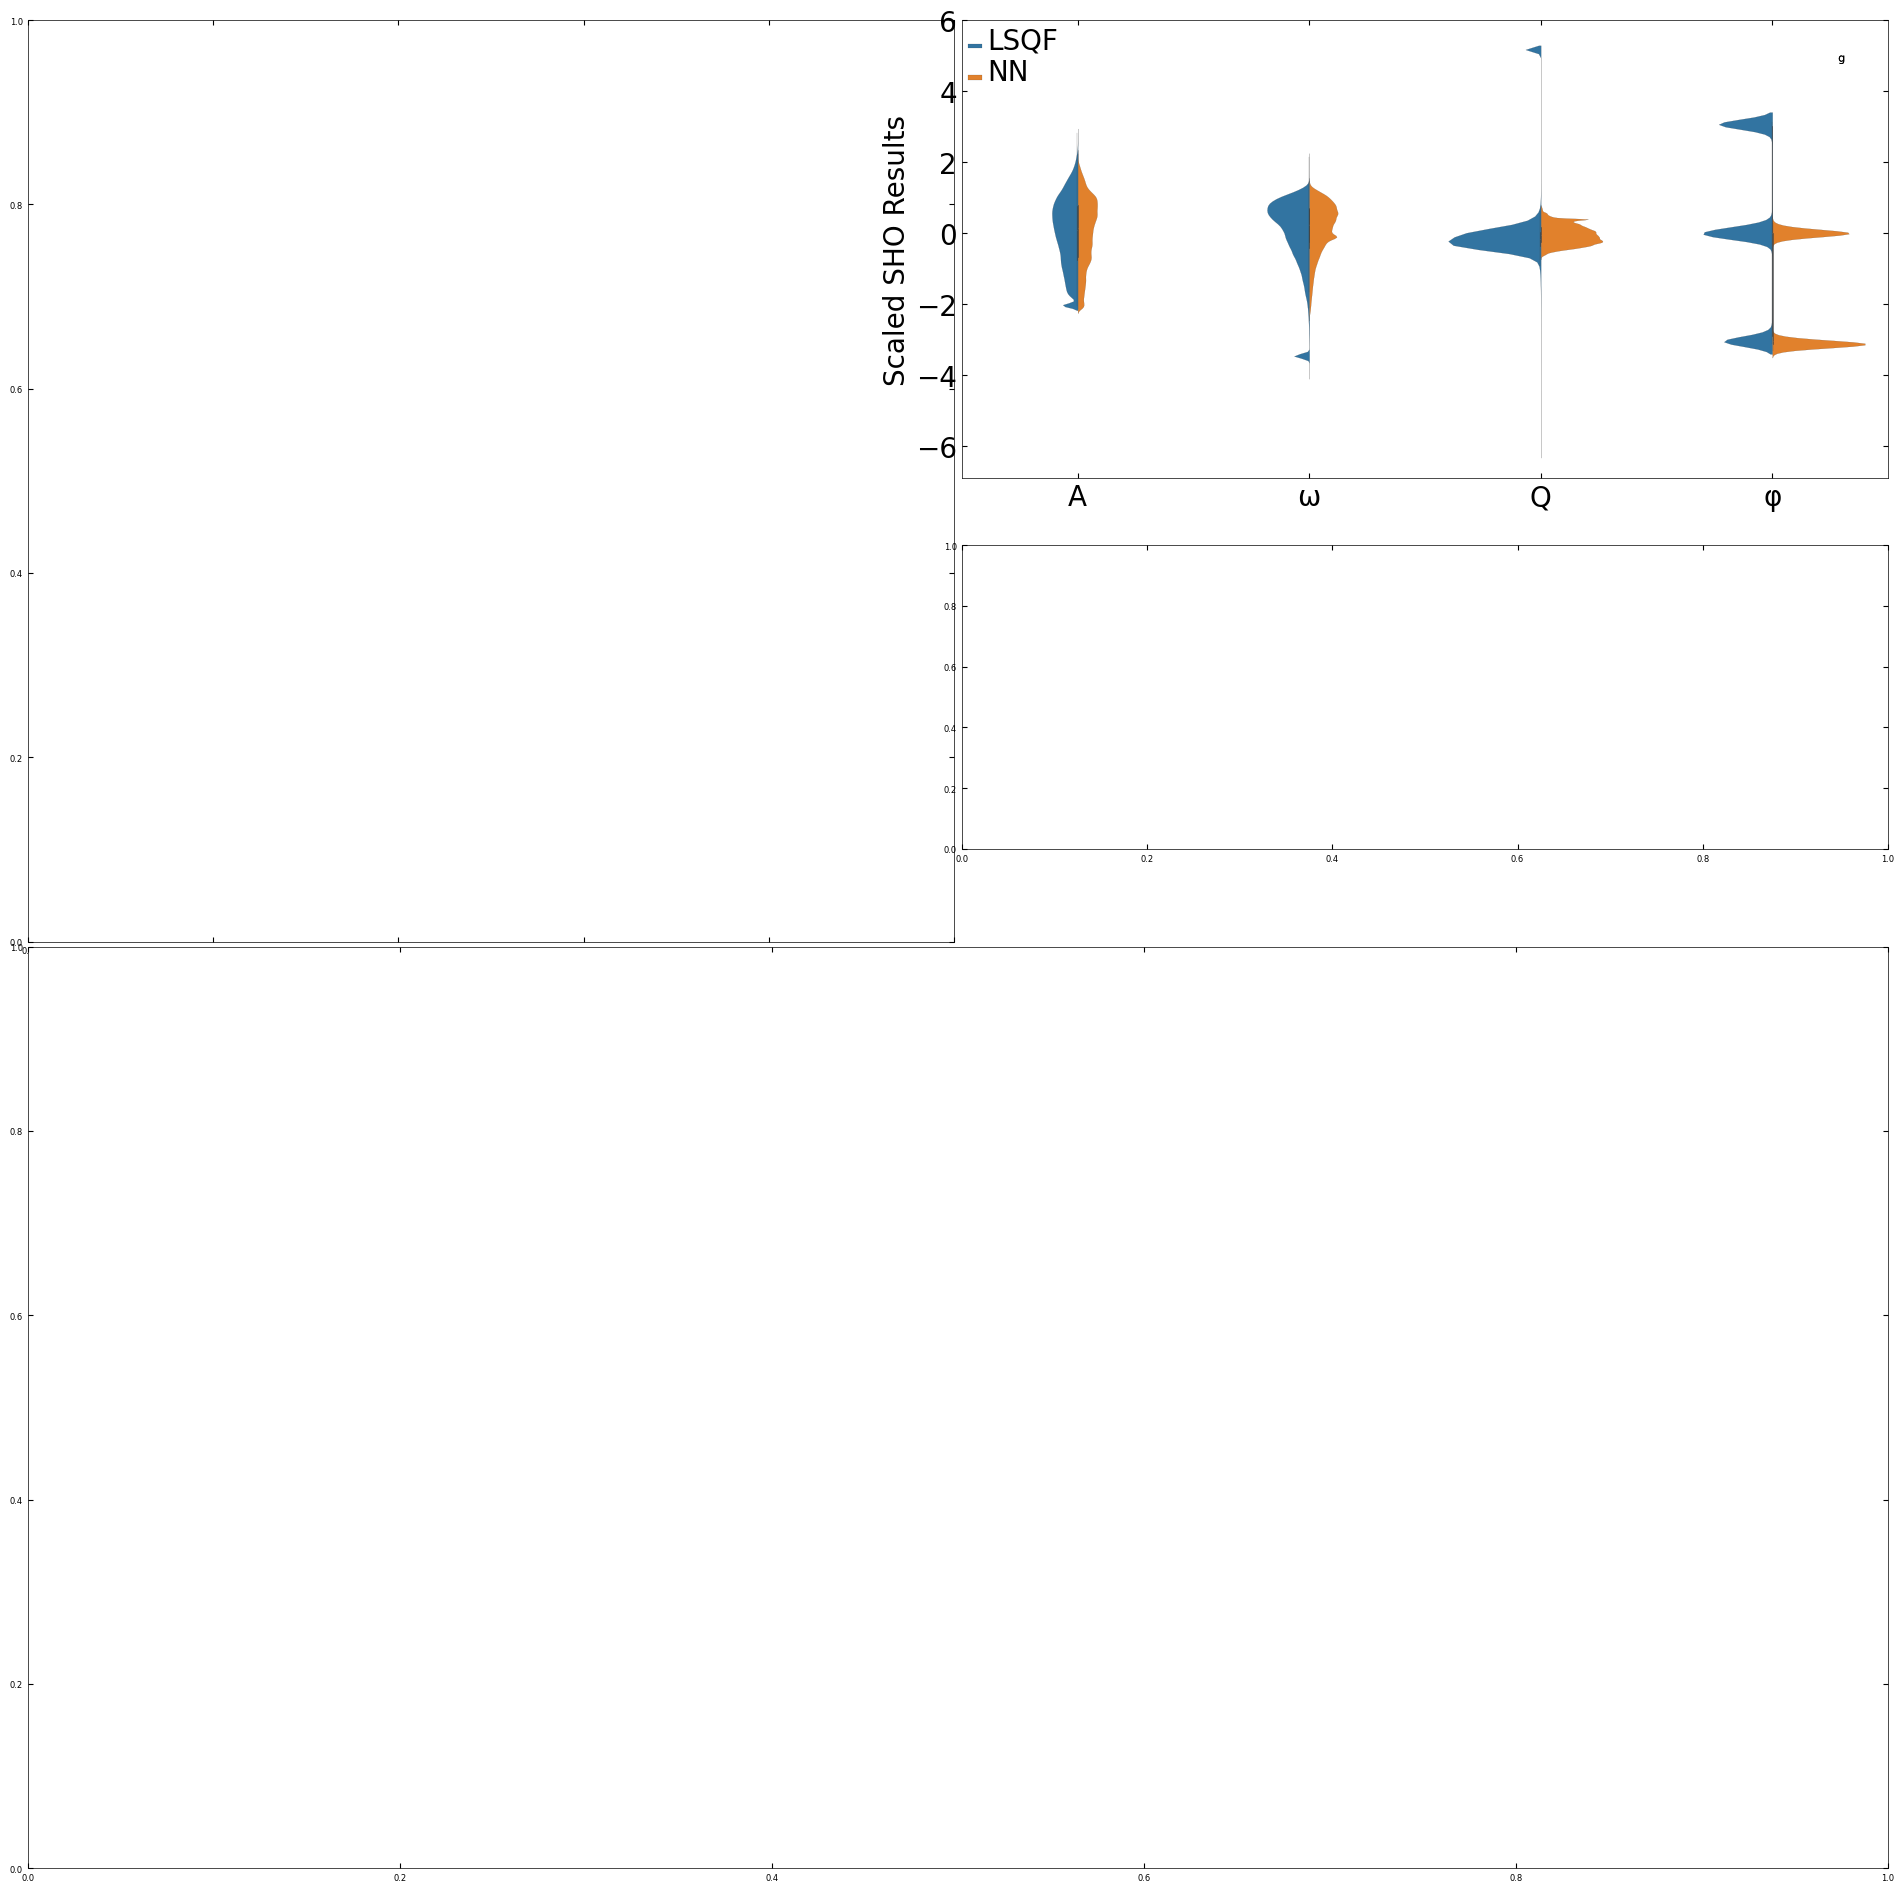

In [16]:
fig

In [10]:
axes.extend(fig.axes)

In [9]:
# sets the phase shift of the dataset
BE_viz.NN_phase_shift = np.pi/2
BE_viz.LSQF_phase_shift = np.pi/2
BE_viz.measurement_state = "all"

# sets the true state which to compare the results.
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

# sets the state of the output data
out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

# sets the number of examples to get
n = 1

##### the problem is that prediction is dict ######

LSQF = BE_viz.get_best_median_worst(
    true_state,
    prediction={"fitter": "LSQF"},
    #model = model,
    out_state=out_state,
    SHO_results=True,
    n=n,
)


In [11]:

NN = BE_viz.get_best_median_worst(
    true_state, prediction=model, out_state=out_state, SHO_results=True, n=n
)

data = (LSQF, NN)
model_names = ["LSQF", "NN"]



./Figures/Figure_14_LSQF_NN_bmw_comparison_2.png
./Figures/Figure_14_LSQF_NN_bmw_comparison_2.svg


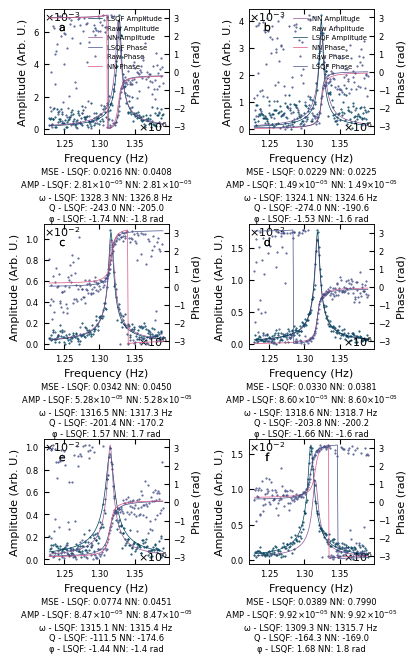

In [12]:


fig,_,_ = BE_viz.SHO_Fit_comparison(
    data,
    model_names,
    model_comparison=[model, {"fitter": "LSQF"}],
    out_state=out_state,
    filename="Figure_14_LSQF_NN_bmw_comparison_2",
    # display_results = None
    
)

In [14]:
axes.extend(fig.axes)

In [66]:
def y_formatter(y, pos):
    return f"{y * 1e3:.1f}"  # Multiply by 1e3 to show scaled values

def copy_axes_properties(row,col,source_ax, target_ax, secondary_ax, ax_lims):
    """Copy properties and data from source_ax to target_ax."""
    # Copy basic properties
    target_ax.set_xlim([1.2,1.4])
    target_ax.set_xticks([1.2,1.3,1.4])
    target_ax.get_xticklabels()[0].set_horizontalalignment('left')
    target_ax.get_xticklabels()[-1].set_horizontalalignment('right')

    if row == 2: # if i in [4,5]:
        target_ax.set_xlabel('Frequency (MHz)',fontsize=20)
    else:
        target_ax.set_xlabel("")
        #target_ax.set_xticks([])
        target_ax.xaxis.set_ticklabels([])

    if col == 0:    
        target_ax.set_ylabel(source_ax.get_ylabel(),fontsize=20)
    else:
        target_ax.set_ylabel("")
        target_ax.yaxis.set_ticklabels([])

        
    if row == 0:
        target_ax.set_ylim([-0.5e-3,8.0e-3])
    elif row == 1: 
        target_ax.set_ylim([-0.1e-2,2.1e-2])
    elif row == 2: 
        target_ax.set_ylim([-0.1e-2,2.1e-2])    
    
    target_ax.set_title(source_ax.get_title())

    # Copy lines from the primary axis
    for line in source_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties like color, linestyle, marker, etc.
        target_ax.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                       linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
        
    # Handle twin axes if present
    #if secondary_ax:
    ax_twin = target_ax.twinx()
    ax_twin.set_ylim(secondary_ax.get_ylim())

    if col == 0: #if i % 2 == 0: 
        ax_twin.set_ylabel("")
        ax_twin.yaxis.set_ticklabels([])
        
        set_sci_notation_label(
                target_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                textsize = 20, offset_points = (0,50)
            )
    else:
        ax_twin.set_ylabel(secondary_ax.get_ylabel(),fontsize = 20)
        ax_twin.set_yticks([-3,-2,-1,0,1,2,3])


    for line in secondary_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties for the twin axis
        ax_twin.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
    
    
    target_ax.tick_params(axis='x',labelsize=18)
    target_ax.tick_params(axis='y',labelsize=18)
    if row == 0 and col == 0: 
        target_ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))

    ax_twin.tick_params(axis='x',labelsize=18)

    ax_twin.tick_params(axis='y',labelsize=18)
    
    plt.tight_layout()


In [64]:
def copy_axis_to(source_ax, target_ax):
    """
    Copies the plot content from source_ax into target_ax, including lines, markers,
    bar plots, annotations, and text.

    Args:
        source_ax (matplotlib.axes.Axes): The axis to copy from.
        target_ax (matplotlib.axes.Axes): The axis to copy into.
    """
    # Copy lines and markers
    for line in source_ax.get_lines():
        target_ax.plot(
            line.get_xdata(),
            line.get_ydata(),
            linestyle=line.get_linestyle(),
            marker=line.get_marker(),
            color=line.get_color(),
            label=line.get_label(),
            markersize=line.get_markersize()
        )

    # Copy bar containers
    for container in source_ax.containers:
        for patch in container:
            target_ax.add_patch(patch)

    # Copy text and annotations
    for txt in source_ax.texts:
        if isinstance(txt, plt.Annotation):
            # Copy annotation with arrows (from annotate)
            target_ax.annotate(
                text=txt.get_text(), 
                xy=txt.xy,
                xytext=txt.get_position(),
                arrowprops=txt.arrowprops if hasattr(txt, 'arrowprops') else None
            )
        else:
            # Copy plain text (from text)
            target_ax.text(
                x=txt.get_position()[0],
                y=txt.get_position()[1],
                s=txt.get_text(),
                fontsize=txt.get_fontsize(),
                color=txt.get_color(),
                ha=txt.get_ha(),
                va=txt.get_va(),
                rotation=txt.get_rotation()
            )

    # # Copy axis properties
    # target_ax.set_xlim(source_ax.get_xlim())
    # target_ax.set_ylim(source_ax.get_ylim())
    # target_ax.set_title(source_ax.get_title())
    # target_ax.set_xlabel(source_ax.get_xlabel())
    # target_ax.set_ylabel(source_ax.get_ylabel())
    # target_ax.legend()

In [76]:
import numpy as np
from matplotlib.image import AxesImage
from matplotlib.transforms import Bbox

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import AxesImage
from matplotlib.patches import Rectangle

def copy_axis_to_canvas_with_manual_layout(
    source_axes,
    target_ax,
    switching_map_horizontal_separation=1/256,
    switching_map_vertical_separation=1/96,
    tile_size = 1 / 12,  # fixed square tile size
    row_padding = 1 / 192,  # ~0.0052 (between all rows)
    x_margin = -0.06,       # left margin
    num_rows = 6,
    num_cols = 12,
    extra_horizontal_tile_spacing = 1/11.8,
    num_tiles_in_group_horizontal = 4,
    num_tiles_in_group_vertical = 2
):
    """
    Copies imshow tiles and annotations/text from a grid of source axes to a single target axis,
    manually laying them out starting from the top-left corner using provided separations.

    Args:
        source_axes: list of  matplotlib Axes, ordered row-wise
        target_ax: single target axis to draw all tiles into
        switching_map_horizontal_separation: horizontal spacing between groups of 4 tiles
        switching_map_vertical_separation: vertical spacing between groups of 2 rows
    """
    

    fig_w, fig_h = target_ax.figure.get_size_inches() * target_ax.figure.dpi
    
    for idx, ax in enumerate(source_axes):
        row = idx // num_cols
        col = idx % num_cols

        # Compute tile top-left position in normalized figure coords
        x_offset = (
            x_margin +
            (col * extra_horizontal_tile_spacing) +                       # uniform spacing
            (np.floor(col / num_tiles_in_group_horizontal)) * switching_map_horizontal_separation            # extra group spacing
        )
        y_offset = (
            1 - (row + 1) * tile_size            # tile height
            - row * row_padding                  # per-row spacing
            - (np.floor(row / num_tiles_in_group_vertical)) * switching_map_vertical_separation
        )

        # Tile extent in [x0, x1, y0, y1] (normalized fig coords)
        extent_norm = [
            x_offset,
            x_offset + tile_size,
            y_offset,
            y_offset + tile_size
        ]

        # Convert normalized coords to target_ax data coords
        ax_box = target_ax.get_position()
        target_fig = target_ax.figure
        target_fig_w, target_fig_h = target_fig.get_size_inches() * target_fig.dpi
        target_x0 = ax_box.x0 * target_fig_w
        target_x1 = ax_box.x1 * target_fig_w
        target_y0 = ax_box.y0 * target_fig_h
        target_y1 = ax_box.y1 * target_fig_h

        def norm_to_target(xn, yn):
            xt = target_x0 + (target_x1 - target_x0) * xn
            yt = target_y0 + (target_y1 - target_y0) * yn
            return xt, yt

        x0_t, y0_t = norm_to_target(extent_norm[0], extent_norm[2])
        x1_t, y1_t = norm_to_target(extent_norm[1], extent_norm[3])
        extent_target = [x0_t, x1_t, y0_t, y1_t]

        # Draw image
        for img in ax.get_images():
            target_ax.imshow(
                img.get_array(),
                extent=extent_target,
                cmap=img.get_cmap(),
                interpolation=img.get_interpolation(),
                vmin=img.get_clim()[0],
                vmax=img.get_clim()[1],
                origin=img.origin,
                alpha=img.get_alpha()
            )

        # Axes bounds for coordinate transforms
        ax_xlim = ax.get_xlim()
        ax_ylim = ax.get_ylim()
        dx = x1_t - x0_t
        dy = y1_t - y0_t

        def local_to_target(x, y):
            xf = (x - ax_xlim[0]) / (ax_xlim[1] - ax_xlim[0])
            yf = (y - ax_ylim[0]) / (ax_ylim[1] - ax_ylim[0])
            return x0_t + xf * dx, y0_t + yf * dy

        # Draw lines
        for line in ax.get_lines():
            xdata, ydata = line.get_xdata(), line.get_ydata()
            xg, yg = zip(*[local_to_target(x, y) for x, y in zip(xdata, ydata)])
            target_ax.plot(
                xg, yg,
                linestyle=line.get_linestyle(),
                marker=line.get_marker(),
                color=line.get_color(),
                markersize=line.get_markersize(),
                linewidth=line.get_linewidth()
            )

        # Draw text and annotations
        for txt in ax.texts:
            pos = txt.get_position()
            xg, yg = local_to_target(*pos)
            if isinstance(txt, plt.Annotation):
                x_anno, y_anno = local_to_target(*txt.xy)
                target_ax.annotate(
                    txt.get_text(), xy=(x_anno, y_anno), xytext=(xg, yg),
                    arrowprops=txt.arrowprops if hasattr(txt, 'arrowprops') else None,
                    fontsize=txt.get_fontsize(),
                    color=txt.get_color()
                )
            else:
                target_ax.text(
                    xg, yg, txt.get_text(),
                    fontsize=txt.get_fontsize(),
                    color=txt.get_color(),
                    ha=txt.get_ha(),
                    va=txt.get_va(),
                    rotation=txt.get_rotation()
                )

        # Draw rectangle patches
        for patch in ax.patches:
            if isinstance(patch, Rectangle):
                x, y = patch.get_xy()
                w, h = patch.get_width(), patch.get_height()
                xg, yg = local_to_target(x, y)
                wg = w * dx / (ax_xlim[1] - ax_xlim[0])
                hg = h * dy / (ax_ylim[1] - ax_ylim[0])
                new_patch = Rectangle(
                    (xg, yg), wg, hg,
                    facecolor=patch.get_facecolor(),
                    edgecolor=patch.get_edgecolor(),
                    linewidth=patch.get_linewidth(),
                    linestyle=patch.get_linestyle(),
                    fill=patch.get_fill(),
                    alpha=patch.get_alpha()
                )
                target_ax.add_patch(new_patch)

    # Final axis limits = full target box in pixel coordinates
    target_ax.set_xlim(target_x0, target_x1)
    target_ax.set_ylim(target_y0, target_y1)
    # DO NOT invert Y



(1382400, 4)
(1382400, 4)


/tmp/ipykernel_1892653/1302063626.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1892653/1302063626.py:390: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 4 Axes> than <Figure size 650x504 with 73 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0],
/tmp/ipykernel_1892653/1302063626.py:407: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 4 Axes> than <Figure size 650x504 with 73 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0],
/tmp/ipykernel_1892653/1302063626.py:413: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 4 Axes> than <Figure size 650x504 with 73 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],location = 'bottom'

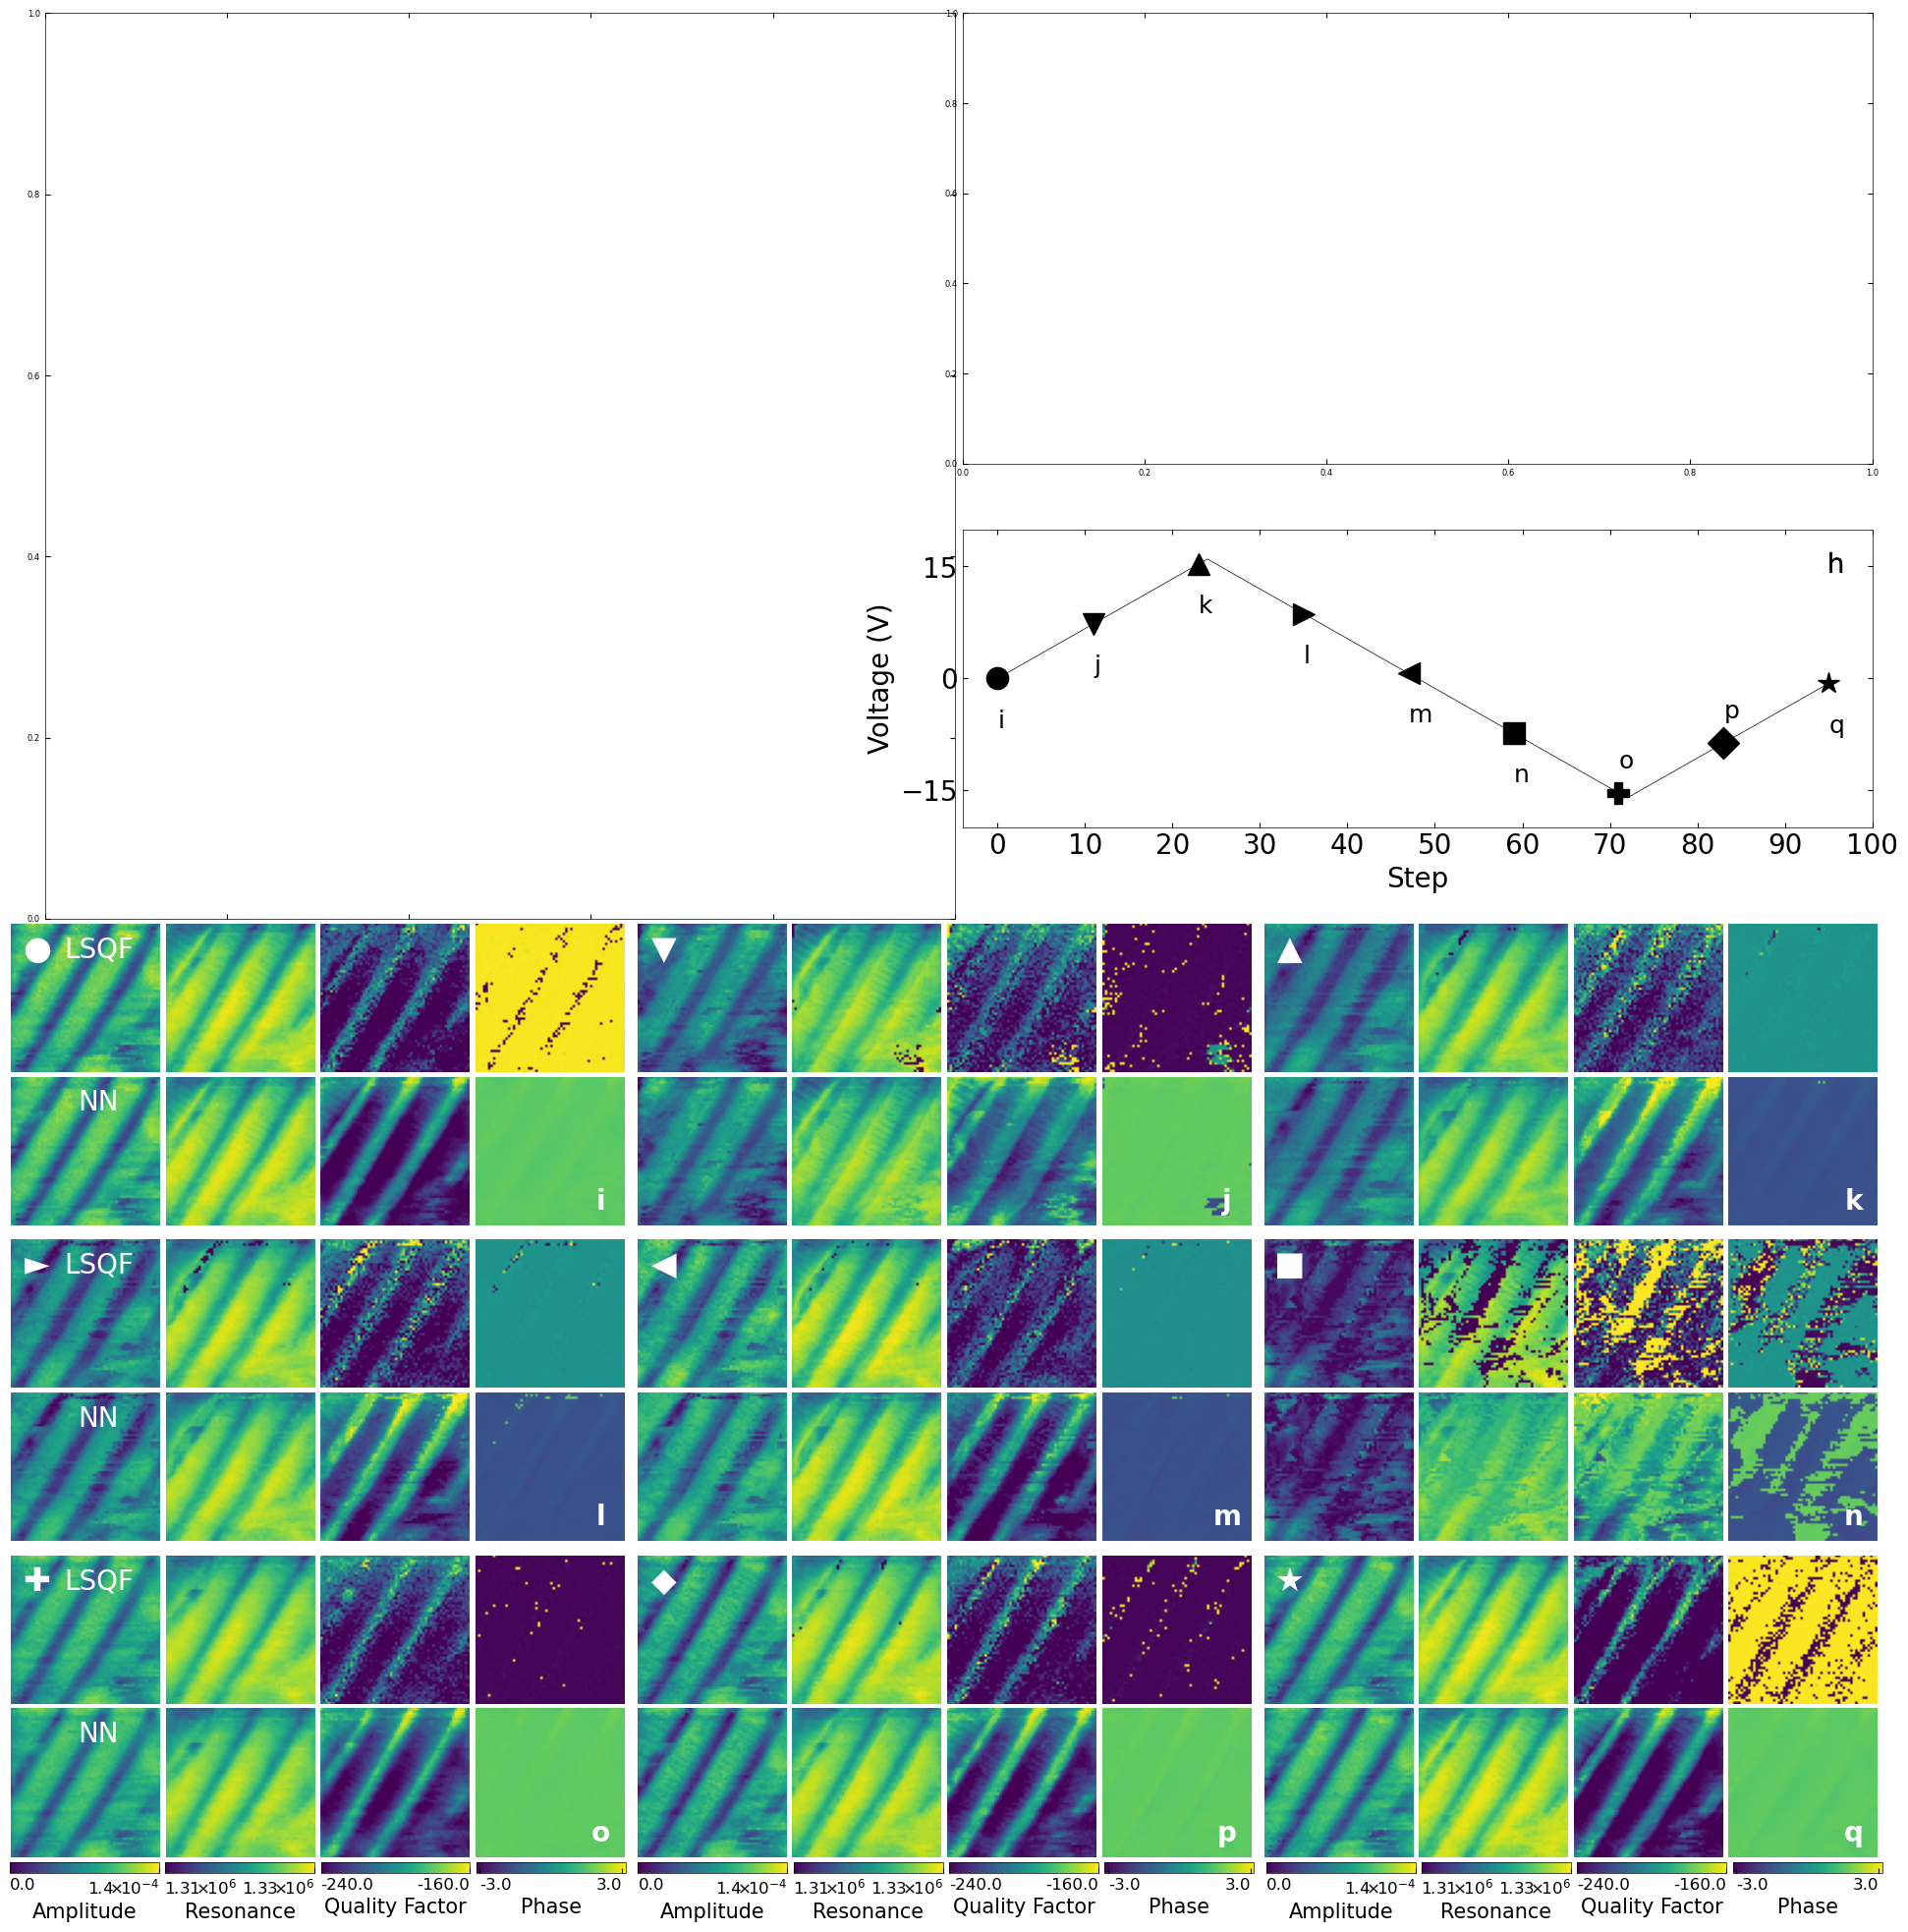

./Figures/Figure_3_test5.png
./Figures/Figure_3_test5.svg


In [126]:

# Create a figure

fig = plt.figure(figsize=(24, 24))


# Define the GridSpec layout
gs = GridSpec(60, 40, figure=fig)

order = [['SHO_fit_comp'],
         ['violin'],
         ['voltage_curve'],
         ['switching_maps']
        ]



subplot_specs = [(0, 30, 0, 20 ), # top left: SHO fit comparisons 
                 (0, 15, 20, 40), # g
                 (17, 27, 20, 40), # h
                 (30, 80, 0, 60), #bottom 
                ]

# define flags for testing to only render certain plots
# maybe delete them now that it works? 
renderViolin = False
renderVoltage = True
renderSwitchingMaps = True
renderBMWComp = False
# Create and set up subplots
for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
        ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])
    #if i < len(axes):
        idx = order[i]
        if idx[0] == 'violin':
            if renderViolin: 
                BE_viz.violin_plot_comparison_SHO(
                    true_state,
                    model,
                    X_data,
                    filename=None,
                    label="NN",
                    ax=ax,
                    figlabel='g',
                    fig_label_size=20
                )
                # df = pd.DataFrame()

                # # scales the parameters
                # scaled_param = BE_viz.SHO_scaler.transform(parm)

                # # gets the parameters from the SHO LSQF fit
                # true = BE_viz.SHO_fit_results(phase_shift=0).reshape(-1, 4)

                # # Builds the dataframe for the violin plot
                # true_df = pd.DataFrame(
                #     true, columns=["Amplitude", "Resonance", "Q-Factor", "Phase"]
                # )
                # predicted_df = pd.DataFrame(
                #     scaled_param, columns=["Amplitude",
                #                         "Resonance", "Q-Factor", "Phase"]
                # )

                # # merges the two dataframes
                # df = pd.concat((true_df, predicted_df))

                # # adds the labels to the dataframe
                # names = [true, scaled_param]
                # names_str = ["LSQF", "NN"]
                # labels = ["A", "\u03C9", "Q", "\u03C6"]

                # # adds the labels to the dataframe
                # for j, name in enumerate(names):
                #     for i, label in enumerate(labels):
                #         dict_ = {
                #             "value": name[:, i],
                #             "parameter": np.repeat(label, name.shape[0]),
                #             "dataset": np.repeat(names_str[j], name.shape[0]),
                #         }

                #         df = pd.concat((df, pd.DataFrame(dict_)))
                
                # # Reset index to handle potential duplicated columns or indices
                # df = df.reset_index(drop=False)
                
                # # plots the data
                # sns.violinplot(
                #     data=df, x="parameter", y="value", hue="dataset", split=True, ax=ax
                # )

                # # labels the figure and does some styling
                # labelfigs(ax, string_add = 'g', loc ='tl',size=22, style="b", inset_fraction=(0.05,0.15))

                ax.set_ylabel("Scaled SHO Results",fontsize=20)
                ax.set_xlabel("")
                
                ax.tick_params(axis='x',labelsize=20)
                ax.tick_params(axis='y',labelsize=20)
                ax.set_yticks(np.linspace(-6,6,7))


                # Get the legend associated with the plot
                legend = ax.get_legend()
                legend.set_title("")
                plt.setp(legend.get_texts(), fontsize=20) # Set the label size
                
        elif idx[0] == "voltage_curve":
            if renderVoltage:
                voltage_and_switching_maps_fig = BE_viz.SHO_switching_maps_test(SHO_ = [LSQF_Params,parm],
                                               labels = ["LSQF", "NN"], 
                                               filename=None,
                                               label_marker_starting_index=8,
                                               label_marker_size=16,
                                               label_letter_text_size=18,
                                               colorbars=False,
                                               )
                copy_axis_to(voltage_and_switching_maps_fig.axes[0], ax)
                # voltage = np.swapaxes(np.atleast_2d(BE_viz.get_voltage), 0, 1).astype(np.float64)
                # voltage = BE_viz.roll_hysteresis(voltage)

                # # # Get indices of the voltage steps to plot
                # inds = np.linspace(0, len(voltage) - 1, 9, dtype=int)

                # # plots the voltage
                # ax.plot(voltage, "k")
                ax.set_ylabel("Voltage (V)",fontsize=20)
                ax.set_xlabel("Step",fontsize=20)
                ax.set_xticks(np.linspace(0,100,11))
                ax.set_xlim([-4,100])
                ax.set_ylim([-20,20])
                ax.set_yticks([-15,0,15])
                ax.tick_params(axis='x',labelsize=20)
                ax.tick_params(axis='y',labelsize=20)

                # label_marker_symbols_for_plt = ["o", "v", "^", ">", "<", "s","P", "D","*"]

                
                # # Plot the data with different markers
                # for i, ind in enumerate(inds):
                #     # this adds the labels to the graphs
                
                #     ax.plot(ind, voltage[ind], label_marker_symbols_for_plt[i], 
                #             color="k", markersize=20)
                #     vshift = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.25

                #     # positions the location of the labels
                #     if voltage[ind] - vshift - 0.15 < ax.get_ylim()[0]:
                #         vshift = -vshift / 2

                #     # # adds the text to the graphs
                #     ax.text(ind, voltage[ind] - vshift,
                #             number_to_letters(i + 8), color="k", fontsize=25)
                    
                    # labelfigs(ax, number = i+8, loc = 'tl', size=20,style='b',
                    #           inset_fraction=(ind,voltage[ind]-vshift))
                plt.tight_layout()
                
                labelfigs(ax,
                    string_add='h',
                    loc ='tl',
                    size=20, #22
                    inset_fraction=(0.12,0.96),
                    style = 'b'
                    )

        elif idx[0] == "switching_maps": # see BE_viz.SHO_switching_maps_test for reference
            if renderSwitchingMaps:
                ax2 = voltage_and_switching_maps_fig.axes[1:]
                #copy_axis_to_canvas_with_manual_layout(voltage_and_switching_maps_fig.axes[1:], ax)

                # clims=[
                #     (0, 1.4e-4),  # amplitude
                #     (1.31e6, 1.33e6),  # resonance frequency
                #     (-230, -160),  # quality factor
                #     (-np.pi, np.pi), # phase
                # ]  
                # number_of_steps = 9
                # SHO_ = [LSQF_Params,parm]
                # comp_number = len(SHO_)

                # rows = np.ceil(number_of_steps * comp_number / 3)
                # cols = 3
                
                
                # fig_width = 6.5
                # intra_gap=0.02  # gap between the graphs,
                # inter_gap=0.05  # gap between the graphs,
                # cbar_gap=0.4  # gap between the graphs of colorbars
                # cbar_space=1.3  # space on the right where the cbar is not
                # voltage_plot_height=1.25  # height of the voltage plot
                # colorbars = True

                        
                # # calculates the size of the embedding image
                # embedding_image_size = (
                #     fig_width
                #     - (inter_gap * (cols - 1))
                #     - intra_gap * 3 * cols
                #     - cbar_space * colorbars
                # ) / (cols * 4)
                
                
                # # calculates the figure height based on the image details
                # fig_height = (
                #     rows * (embedding_image_size + inter_gap)
                #     + voltage_plot_height
                #     + 0.33
                #     + inter_gap * (comp_number - 1)
                # )

                # # defines a scalar to convert inches to relative coordinates
                # fig_scalar = FigDimConverter((fig_width, fig_height))
                # fig = plt.figure(figsize=(fig_width, fig_height))

                # ax2 = [] 
                
                #     # Define the position and size of the voltage plot
                # pos_inch = [
                #     0.33,
                #     fig_height - voltage_plot_height,
                #     fig_width - 0.33,
                #     voltage_plot_height,
                # ]
                
                # # adds the plot for the voltage
                # #ax2.append(fig.add_axes(fig_scalar.to_relative(pos_inch)))
                
                # #len(ax) here should be 1
                
                
                
                # # resets the x0 position for the embedding plots
                # pos_inch[0] = 0
                # pos_inch[1] -= embedding_image_size + 0.33

    
                # # sets the embedding size of the image
                # pos_inch[2] = embedding_image_size
                # pos_inch[3] = embedding_image_size
                
                #     # This makes the figures
                # for k, _SHO in enumerate(SHO_):
                #     # adds the embedding plots
                #     for i in range(number_of_steps):
                #         # loops around the amp, phase, and freq
                #         for j in range(4):
                #             # adds the plot to the figure
                #             ax2.append(fig.add_axes(fig_scalar.to_relative(pos_inch)))

                #             # adds the inter plot gap
                #             pos_inch[0] += embedding_image_size + intra_gap

                #         # if the last column in row, moves the position to the next row
                #         if (i + 1) % cols == 0 and i != 0:
                #             # resets the x0 position for the embedding plots
                #             pos_inch[0] = 0

                #             # moves the y0 position to the next row
                #             pos_inch[1] -= embedding_image_size + inter_gap

                #             if (i + 1) % (cols * comp_number) == 0 and comp_number > 1:
                #                 pos_inch[1] -= inter_gap

                #         else:
                #             # adds the small gap between the plots
                #             pos_inch[0] += inter_gap
              
                
                # for k, _SHO in enumerate(SHO_):
                #     # converts the data to a numpy array
                #     if isinstance(_SHO, torch.Tensor):
                #         _SHO = _SHO.detach().numpy()

                #     print(_SHO.shape)
                #     _SHO = _SHO.reshape(BE_viz.num_pix,
                #                         BE_viz.voltage_steps, 4)

                #     # get the selected measurement cycle
                #     # TODO: maybe don't hardcode cycle=2? 
                #     _SHO = BE_viz.get_measurement_cycle(_SHO, cycle=2,axis=1)

                #     names = ["A", "\u03C9", "Q", "\u03C6"]
                #     names_str = ["LSQF", "NN"]
                #     voltage = np.swapaxes(np.atleast_2d(BE_viz.get_voltage), 0, 1).astype(np.float64)
                #     voltage = BE_viz.roll_hysteresis(voltage)

                #     # gets the index of the voltage steps to plot
                #     inds = np.linspace(0, len(voltage) - 1, number_of_steps, dtype=int)
                #     for i, ind in enumerate(inds):
                #         axis_start = int(
                #             (i % cols) * 4
                #             + ((i) // cols) * (comp_number * cols * 4)
                #             + k * (cols * 4)
                #             + 1
                #         )

                #         # loops around the amp, resonant frequency, and Q, Phase
                #         for j in range(4):
                #             imagemap(
                #                 ax2[axis_start + j-1],
                #                 _SHO[:, ind, j],
                #                 colorbars=False,
                #                 cmap="viridis",
                #             )

                #             if i // rows == 0 and k == 0:
                #                 labelfigs(
                #                     ax2[axis_start + j-1],
                #                     string_add=names[j],
                #                     loc="cb",
                #                     size=5,
                #                     inset_fraction=(0.2, 0.2),
                #                 )

                #             ax2[axis_start + j-1].images[0].set_clim(clims[j])

                #             if k == 0:
                #                 labelfigs(
                #                     ax2[axis_start + j-1],
                #                     string_add=str(i + 1),
                #                     size=5,
                #                     loc="bl",
                #                     inset_fraction=(0.2, 0.2),
                #                 )

                #             if (axis_start + j) % (4 * cols) == 1:
                #                 ax2[axis_start + j-1].set_ylabel(names_str[k])
                
                label_marker_symbols = ["\u25CF", "\u25BC", "\u25B2", "\u25BA", "\u25C0", "\u25A0","\u271A", "\u25C6","\u2605"]
                label_marker_symbols_counter = 0
                
                
                labels = ['i','j','k','l','m','n','o','p','q']
                label_counter = 0
                names = ['Amplitude', "Resonance","Quality Factor","Phase"]
                clims=[
                        (0, 1.4e-4),  # amplitude
                        (1.31e6, 1.33e6),  # resonance frequency
                        (-240, -160),  # quality factor
                        (-np.pi, np.pi),  # phase
                    ],  # phase limits
                # scalar_formatter = ScalarFormatter(useMathText=True)
                # scalar_formatter.set_powerlimits((0, 0))
                # defines a scalar to convert inches to relative coordinates
                fig_scalar = FigDimConverter((1/6, 1/6))
                #fig_scalar = FigDimConverter((fig_width, fig_height))
                
                for row in range(6):
                    for col in range(12):
                        inset_ax = ax.inset_axes([-0.06+(col/11.8)+np.floor(col/4)/256,1-(row+1)/6.1-row/192-np.floor(row/2)/96,1/6.1,1/6.1])

                        inset_ax.imshow(ax2[(12*row)+col].get_images()[0].get_array().data,clim = clims[0][int(np.floor(col % 4))])
                        if col == 0:
                            if row % 2 == 0: 
                                inset_ax.text(35,10,ax2[0].get_ylabel(),color = "white",size=20,ha = "center", va = "center")
                            
                            else:
                                inset_ax.text(35,10,ax2[12].get_ylabel(),color = "white", size=20,ha = "center", va = "center")
                        
                        if row % 2 == 0 and col % 4 == 0: 
                                inset_ax.text(10,10, label_marker_symbols[label_marker_symbols_counter], color = "white", size = 24, ha = "center", va = "center")
                                label_marker_symbols_counter+=1
                        elif row % 2 == 1 and (col + 1) % 4 == 0:
                            inset_ax.text(50,50, labels[label_counter], color = "white", weight = 'bold', size = 20,ha = "center", va = "center")
                            label_counter+=1 
                            
                        if row == 5:
                            
                            
                            # fmt = ScalarFormatter(useMathText=True)
                            # fmt.set_powerlimits((0, 0))
                                        
                            bar_ax = []
                            pos_inch = [-3.2e-3 + (col/70.5)+np.floor(col/4)/1800, -0.008, 1/73.5, 1/500  ] #fills axes
                          
                            bar_ax.append(ax.inset_axes(fig_scalar.to_relative(pos_inch)))
                            
                            def fmt(x, pos):
                                    a, b = '{:.1e}'.format(x).split('e')
                                    b = int(b)
                                    if abs(b) >2: 
                                        #return r'${} \times 10^{{{}}}$'.format(a, b)
                                        return rf'$\hspace{{{-1.1}}} {a} \hspace{{{-0.4}}} \times \hspace{{{-0.4}}} 10^{{{b}}}$'
                                    else: 
                                        return float(a)*10**b
                                    
                                    
                                    
                            if int(np.floor(col % 4)) == 0:
                                                  
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), 
                                                    ticks = np.linspace(np.min(clims[0][int(np.floor(col % 4))]),
                                                                        np.max(clims[0][int(np.floor(col % 4))]),2), #5
                                                  
                                                    )
                                cbar.ax.get_xticklabels()[0].set_horizontalalignment('left')
                                cbar.ax.get_xticklabels()[1].set_horizontalalignment('right')

                            elif int(np.floor(col % 4)) == 1:
                                
                                def fmt_Resonance(x, pos): #need to display more digits to differentiate the resonance values
                                    a, b = '{:.2e}'.format(x).split('e')
                                    b = int(b)
                                    #return r'${} \!\! \mspace{-1} \times \!\! 10^{{{}}}$'.format(a, b)
                                    return rf'$\hspace{{{-1.1}}} {a} \hspace{{{-0.4}}} \times \hspace{{{-0.4}}} 10^{{{b}}}$'
                                
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt_Resonance), #fmt, 
                                                    ticks = np.linspace(np.min(clims[0][int(np.floor(col % 4))]),
                                                                        np.max(clims[0][int(np.floor(col % 4))]),2) #5
                                                    )
                            elif int(np.floor(col % 4)) == 2:
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), 
                                                    ticks = np.linspace(np.min(clims[0][int(np.floor(col % 4))]),
                                                                        np.max(clims[0][int(np.floor(col % 4))]),2) # 5
                                                    )
                            else:
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), 
                                                    ticks = np.linspace(-3,3,2)
                                                    ) 
                            
                            cbar.ax.get_xticklabels()[0].set_horizontalalignment('left')
                            cbar.ax.get_xticklabels()[1].set_horizontalalignment('right')
                            cbar.ax.tick_params(labelsize = 12)
                            cbar.set_label(names[int(np.floor(col % 4))],size=15)  # Add a label to the colorbar

                        inset_ax.axis("off")
                
                ax.axis("off")
                plt.close(voltage_and_switching_maps_fig)       
            
        else:
            if renderBMWComp:
                ax.axis("off")
                # BMW_comp_fig,list_ax_,list_ax1 = BE_viz.SHO_Fit_comparison(
                #     data=data,
                #     names=model_names,
                #     model_comparison=[model, {"fitter": "LSQF"}],
                #     out_state=out_state,
                #     filename = None,
                #     SHO_results=True,
                #     n=n,
                # )
                 
   

                # # Defines the color palettes for the plots
                # color_palette = {
                #     "LSQF_A": "#003f5c",  # dark blue
                #     "LSQF_P": "#444e86",  # bluish purple
                #     "NN_A": "#955196",  # purple
                #     "NN_P": "#dd5182",  # pinkish red
                #     "real": "#ff6e54",  # orange
                #     "imag": "#ffa600",  # yellow-orange
                #     "mag": "#2f9eaa",  # cyan
                #     "phase": "#66c21f",  # green
                # }

                # # sets the phase shift of the dataset
                # BE_viz.NN_phase_shift = np.pi/2
                # BE_viz.LSQF_phase_shift = np.pi/2
                # BE_viz.measurement_state = "all"

                # # sets the true state which to compare the results.
                # true_state = {
                #     "fitter": "LSQF",
                #     "raw_format": "complex",
                #     "resampled": True,
                #     "scaled": True,
                #     "output_shape": "index",
                #     "measurement_state": "all",
                # }

                # # sets the state of the output data
                # out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

                # #out_state = {"scaled": True, "raw_format": "complex"}


                # # sets the number of examples to get
                # n = 1

                # LSQF = BE_viz.get_best_median_worst(
                #     true_state,
                #     prediction={"fitter": "LSQF"},
                #     out_state=out_state,
                #     SHO_results=True,
                #     n=n,
                # )

                # NN = BE_viz.get_best_median_worst(
                #     true_state, prediction=model, out_state=out_state, SHO_results=True, n=n
                # )
                # # from BE_viz.SHO_fit_comparison 
                
                # data = (LSQF, NN)
                # names = ["LSQF", "NN"]
                # model_comparison=[model, {"fitter": "LSQF"}]
                # out_state=out_state
                # gaps=(0.8, 0.1)
                # size=(1.25, 1.25)
                # #display_results="all"
                
                # # Get the number of fits from the length of the data list
                # num_fits = len(data)
                
                # # Create subplots for the comparison
                # fig_SHO_comp, ax_SHO_comp = subfigures(3, num_fits, gaps=gaps, size=size)
                
                # list_ax_ = []
                # list_ax1 = [] 
                            
                # # Loop through each fit and the associated data
                # for step, (data, name) in enumerate(zip(data, names)):
                #     # Unpack the data (true, predicted values, indices, etc.)
                #     d1, d2, x1, x2, label,full_labels, index1, mse1, params = data

                #     # Loop through datasets for comparison (true vs. predicted data)
                #     for bmw, (true, prediction, error, SHO, index1) in enumerate(
                #         zip(d1, d2, mse1, params, index1)
                #     ):
                #         # Initialize dictionaries for errors and SHO parameters
                #         errors = {}
                #         SHOs = {}

                #         # Determine the subplot index
                #         index = bmw * num_fits + step
                #         ax_ = ax_SHO_comp[index]

                #         # Plot predicted amplitude and phase
                #         ax_.plot(
                #             x2,
                #             prediction[0].flatten(),
                #             color=color_palette[f"{name}_A"],
                #             label=f"{name} {label[0]}",
                #         )
                #         ax1 = ax_.twinx()
                #         ax1.plot(
                #             x2,
                #             prediction[1].flatten(),
                #             color=color_palette[f"{name}_P"],
                #             label=f"{name} {label[1]}",
                #         )

                #         # Plot true amplitude and phase
                #         ax_.plot(
                #             x1,
                #             true[0].flatten(),
                #             "o",
                #             color=color_palette["LSQF_A"],
                #             label=f"Raw {label[0]}",
                #         )
                #         ax1.plot(
                #             x1,
                #             true[1].flatten(),
                #             "o",
                #             color=color_palette["LSQF_P"],
                #             label=f"Raw {label[1]}",
                #         )

                #         # Store errors and SHO parameters for the current model
                #         errors[name] = error
                #         SHOs[name] = SHO
                        
                        
                #         if model_comparison[step] is not None:
                #             # Get SHO parameters from the comparison model
                #             pred_data, params, labels = BE_viz.get_SHO_params(
                #                 index1, model=model_comparison[step], out_state=out_state
                #             )

                #             # Determine the color prefix based on model type (NN or LSQF)
                #             if isinstance(model_comparison[step], nn.Module):
                #                 color = "NN"
                #             elif isinstance(model_comparison[step], dict):
                #                 color = "LSQF"

                #             # Store errors and SHO parameters for the comparison model
                #             errors[color] = BE_viz.get_mse_index(
                #                 index1, model_comparison[step]
                #             )
                #             SHOs[color] = np.array(params).squeeze()

                #             # Plot the comparison data
                #             ax_.plot(
                #                 x2,
                #                 pred_data.squeeze()[0].flatten(),
                #                 color=color_palette[f"{color}_A"],
                #                 label=f"{color} {labels[0]}",
                #             )
                #             ax1.plot(
                #                 x2,
                #                 pred_data.squeeze()[1].flatten(),
                #                 color=color_palette[f"{color}_P"],
                #                 label=f"{color} {labels[1]}",
                #             )
                            
                #         # Set the x-axis label (Frequency in MHz)
                #         ax_.set_xlabel("Frequency (MHz)")
                    
                #         if (
                #             "raw_format" in out_state.keys()
                #             and out_state["raw_format"] == "magnitude spectrum"
                #         ):
                #             ax_.set_ylabel("Amplitude (Arb. U.)")
                #             ax1.set_ylabel("Phase (rad)")
                #         else:
                #             ax_.set_ylabel("Real (Arb. U.)")
                #             ax1.set_ylabel("Imag (Arb. U.)")
                            
                        
                #         # Add legend for the last fit
                #         if index < num_fits:
                #             lines, labels = ax_.get_legend_handles_labels()
                #             lines2, labels2 = ax1.get_legend_handles_labels()
                #             ax_.legend(lines + lines2, labels + labels2, loc="upper right")
                        
                #         set_sci_notation_label(ax_,axis="x",corner = "bottom right")
                        
                        
                        
                #         list_ax_.append(ax_)
                #         list_ax1.append(ax1)
                        
                #         plt.tight_layout()
                    
                        
                # the order of the plots in the paper seem to be different 
                # from the order of the plots in the code.
                # To make them match, put the plots in the following order: 
                axes_index = [0,3,1,4,2,5]
                        
                for row in range(3):
                    for col in range(2):
                        inset_ax = ax.inset_axes([(col/2)-col*0.18,1-(row+1)/3.25,1/3.25,1/3.25])
                        if col == 0: 
                            copy_axes_properties(row,col,list_ax_[axes_index[2*row+col]], inset_ax, list_ax1[axes_index[2*row+col]],list_ax_[axes_index[2*row+col+1]])
                        else:
                            copy_axes_properties(row,col,list_ax_[axes_index[2*row+col]], inset_ax, list_ax1[axes_index[2*row+col]],list_ax_[axes_index[2*row+col-1]])
                    
                        if row == 0:
                            labelfigs(inset_ax,
                                    string_add="Best",
                                    loc ='tl',
                                    size=20,
                                    inset_fraction=(0.05,0.5),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                            if col == 1:
                                # get legend handles and their corresponding labels
                                handles1, labels1 = inset_ax.get_legend_handles_labels()
                                handles2, labels2 = list_ax1[axes_index[2*row+col]].get_legend_handles_labels()
                                
                                inset_ax.legend(handles1 + handles2,labels1+labels2, loc=(1.25,0.45),fontsize = 14)

                        elif row == 1:
                            labelfigs(inset_ax,
                                    string_add="Median",
                                    loc ='tl',
                                    size=20,
                                    inset_fraction=(0.05,0.5),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                            
                        elif row == 2:
                            labelfigs(inset_ax,
                                    string_add="Worst",
                                    loc ='tl',
                                    size=20,
                                    inset_fraction=(0.05,0.5),
                                    style = 'b',
                                    horizontalalignment="center"
                                    )
                            ax.set_xticks([1.2,1.3,1.4])
                            
                        
                        labelfigs(inset_ax,
                            number=2*row+col,
                            loc ='tl',
                            size=20,
                            inset_fraction=(0.05,0.95),
                            style = 'b'
                            )


# Adjust the spacing between the plots as needed
plt.tight_layout()

# Show the layout
plt.show()

BE_viz.printer.savefig(
                ax.figure, "Figure_3_test5"
            )



In [115]:
r'${0} \mspace{{{1}}} \times 10^{{{1}}}$'.format(3, 4)

'$3 \\mspace{4} \\times 10^{4}$'

In [116]:
r'$1.31\times10^{6}$'

'$1.31\\times10^{6}$'

In [18]:
names

['Amplitude', 'Resonance', 'Quality Factor', 'Phase']

1

In [103]:
print(type(voltage_and_switching_maps_fig.axes[0]))
print(type(voltage_and_switching_maps_fig.axes[1:]))

<class 'matplotlib.axes._axes.Axes'>
<class 'list'>


In [12]:
len(voltage_and_switching_maps_fig.axes[1:])

76

In [22]:
ax.containers

[]

In [21]:
voltage_and_switching_maps_fig.axes[-1].containers

[]

In [88]:
ax1_list=[]
for axis in list_ax1:
    ax1_list.append(axis)


TypeError: 'Axes' object is not iterable

In [86]:
list_ax_[0]

IndexError: list index out of range

In [70]:
np.linspace(0,BE_viz.roll_hysteresis(np.swapaxes(np.atleast_2d(BE_viz.get_voltage), 0, 1).astype(np.float64))-1, 9, dtype=int)

array([[[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [ 

# Figure 4

# try plt.close to prevent display of internal fig

In [38]:
BE_viz.loop_fit_preprocessing()


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


In [39]:
#from m3_learning.be.loop_fitter import loop_fitting_function_torch
from m3util.ml.optimizers.TrustRegion import TRCG
import torch.optim as optim
from belearn.functions.hysteresis import hysteresis_nn

set_seeds(seed=42)
datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter"
device = 'cuda:0'

data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)
# V = np.swapaxes(np.atleast_2d(dataset.get_voltage), 0, 1).astype(np.float64)


model_ = Multiscale1DFitter(
            #BE_viz.loop_fitting_function_torch, # function 
                hysteresis_nn,  # function

                            voltage[:,0].squeeze(), # x data
#                             V.squeeze(),
                            1, # input channels
                            9, # output parameters
                            BE_viz.loop_param_scaler,
                            loops_scaler=BE_viz.hysteresis_scaler,
                            device=device
                            )

# instantiate the model
model = Model(model_, BE_viz, training=True, model_basename="SHO_Fitter_original_data",
                datafed_path=datafed_path,
                script_path="./Paper_Figures.ipynb",
                device=device)



from sklearn.model_selection import train_test_split


X_train, X_test = train_test_split(data.reshape(-1,96), test_size=0.2, random_state=42, shuffle=True)

X_train = np.atleast_3d(X_train)

optimizer = {
    "name": "TRCG", 
    "optimizer": TRCG,
    "closure_size": 1,
    "cgopttol": 1e-3,
    "c0tr": 0.2,
    "c1tr": 0.25,
    "c2tr": 0.75,
    "t1tr": 0.75,
    "t2tr": 2.0,
    "radius_max": 5.0,  
    "radius_initial": 1.0,
    "radius" : 1.0,
    "device": device,
    "ADAM_epochs": 100}


train =  False # SHOULD BE True but setting to False for now for testing 

if train:
    # fits the model
    model.fit(
        X_train,
        1024,
        optimizer=optimizer,
        epochs = 500,
    )
else:
    model.load(
       # "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth"
       "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_499_train_loss_0.005630633379850123.pth"
    )

Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/AutoPhysLearn/src/autophyslearn/spectroscopic/nn.py:780: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path,map_loca

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_example['Original Index'] = int(best_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worst_example['Original Index'] = int(worst_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

./Figures/Figure_XX_LSQF_NN_bmw_comparison_test3.png
./Figures/Figure_XX_LSQF_NN_bmw_comparison_test3.svg


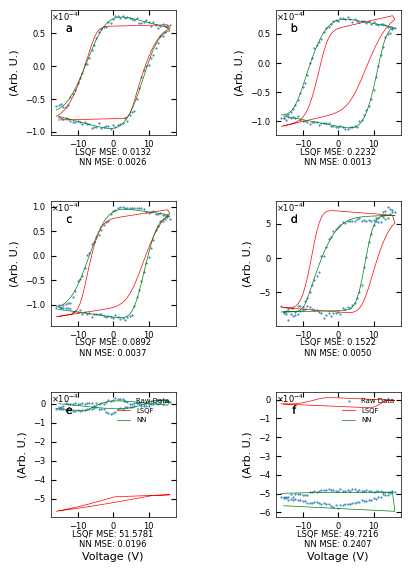

In [7]:
n = 1

data_names = ("LSQF", "NN")

fig = BE_viz.hysteresis_comparison(
    data_names,
    nn_model=model,
    filename="Figure_XX_LSQF_NN_bmw_comparison_test3",
)

In [16]:
axes = fig.axes

In [17]:
axes

[<Axes: ylabel='LSQF'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='NN'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='LSQF'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='NN'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='LSQF'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='NN'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >]

In [21]:
BE_viz.scaled

True

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


AttributeError: 'Viz' object has no attribute 'hysteresis_scaler_'

In [20]:
data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)

fig = BE_viz.violin_plot_comparison_hysteresis(model,
                                         torch.atleast_3d(torch.tensor(data.reshape(-1, 96))),
                                         filename="Figure_XX_Violin2") 

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


AttributeError: 'Viz' object has no attribute 'hysteresis_scaler_'

In [31]:
ax.plot(fig.axes[0].get_lines()[0].get_xdata(),fig.axes[0].get_lines()[0].get_ydata())

In [26]:
fig.axes[0].get_lines()[0].get_xdata()

array([0., 0.])

AttributeError: 'Figure' object has no attribute 'df'

In [20]:
axes.extend(fig.axes)

In [40]:
data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)
data = torch.atleast_3d(torch.tensor(data.reshape(-1, 96)))

pred_recon, pred_params_scaled, pred_params = model.predict(
    data,
    1024,
    translate_params=False,
    is_SHO=False
)


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


use printing function
./Figures/Figure_XX_NN_Hysteresis_Maps_test3.png
./Figures/Figure_XX_NN_Hysteresis_Maps_test3.svg


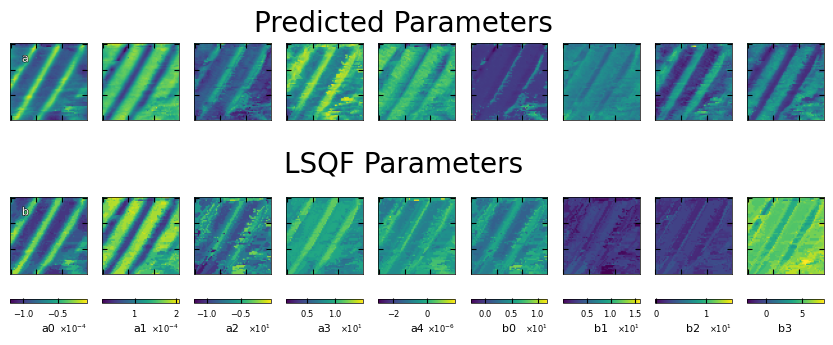

In [41]:
fig = BE_viz.hysteresis_maps(pred_params, cycle=0, filename="Figure_XX_NN_Hysteresis_Maps_test3")



[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='a0'>,
 <Axes: xlabel='a1'>,
 <Axes: xlabel='a2'>,
 <Axes: xlabel='a3'>,
 <Axes: xlabel='a4'>,
 <Axes: xlabel='b0'>,
 <Axes: xlabel='b1'>,
 <Axes: xlabel='b2'>,
 <Axes: xlabel='b3'>]

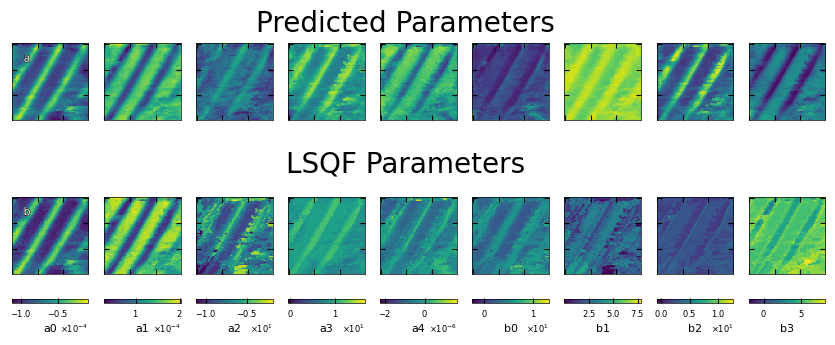

In [93]:
BE_viz.hysteresis_maps(pred_params, cycle=0, filename=None).get_axes()

In [64]:
fig.axes

[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='a0'>,
 <Axes: xlabel='a1'>,
 <Axes: xlabel='a2'>,
 <Axes: xlabel='a3'>,
 <Axes: xlabel='a4'>,
 <Axes: xlabel='b0'>,
 <Axes: xlabel='b1'>,
 <Axes: xlabel='b2'>,
 <Axes: xlabel='b3'>]

In [96]:
5 //9

0

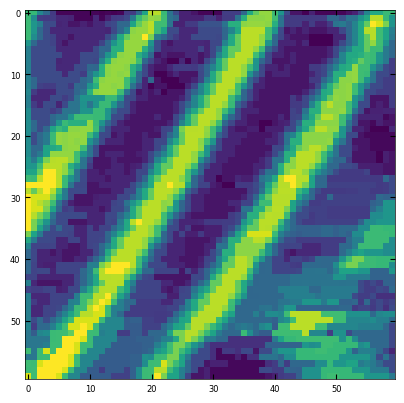

In [62]:

plt.imshow(fig.axes[9].images[0].get_array())

In [7]:
import pandas as pd
import seaborn as sns
import itertools
from torch import nn

from matplotlib.ticker import ScalarFormatter
#from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import EngFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter


from m3util.viz.layout import (
    layout_fig,
    add_box,
    inset_connector,
    scalebar,
    imagemap,
    FigDimConverter,
    subfigures,
    get_axis_pos_inches,
    draw_line_with_text,
)

from m3util.viz.text import (
    add_text_to_figure,
    set_sci_notation_label,
    labelfigs,
    obj_offset,
)




In [8]:
def y_formatter(y, pos):
    return f"{y * 1e3:.1f}"  # Multiply by 1e3 to show scaled values

def copy_axes_properties(row,col,source_ax, target_ax, secondary_ax, ax_lims):
    """Copy properties and data from source_ax to target_ax."""
    # Copy basic properties
    target_ax.set_xlim([-20,20])

    if row == 2: 
        target_ax.set_xlabel('Frequency (MHz)',fontsize=20)
    else:
        target_ax.set_xlabel("")
        target_ax.xaxis.set_ticklabels([])

    if col == 0:    
        target_ax.set_ylabel(source_ax.get_ylabel(),fontsize=20)
    else:
        target_ax.set_ylabel("")
        target_ax.yaxis.set_ticklabels([])

    target_ax.set_title(source_ax.get_title())

    # Copy lines from the primary axis
    for line in source_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties like color, linestyle, marker, etc.
        target_ax.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                       linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
        
    # Handle twin axes if present
    #if secondary_ax:
    ax_twin = target_ax.twinx()
    ax_twin.set_ylim(secondary_ax.get_ylim())

    if col == 0: #if i % 2 == 0: 
        ax_twin.set_ylabel("")
        ax_twin.yaxis.set_ticklabels([])

        
        set_sci_notation_label(
                target_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                textsize = 10, offset_points = (0,30)
            )
    else:
        ax_twin.set_ylabel(secondary_ax.get_ylabel(),fontsize = 20)
        ax_twin.set_yticks([-3,-2,-1,0,1,2,3])

    for line in secondary_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties for the twin axis
        ax_twin.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)

    target_ax.tick_params(axis='x',labelsize=20)
    target_ax.tick_params(axis='y',labelsize=20)
    if row == 0 and col == 0: 
        target_ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))



    ax_twin.tick_params(axis='x',labelsize=20)

    ax_twin.tick_params(axis='y',labelsize=20)
    
    plt.tight_layout()

# Create a figure


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/tmp/ipykernel_2193813/1264522956.py:120: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 3 Axes> than <Figure size 1050x400 with 27 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],


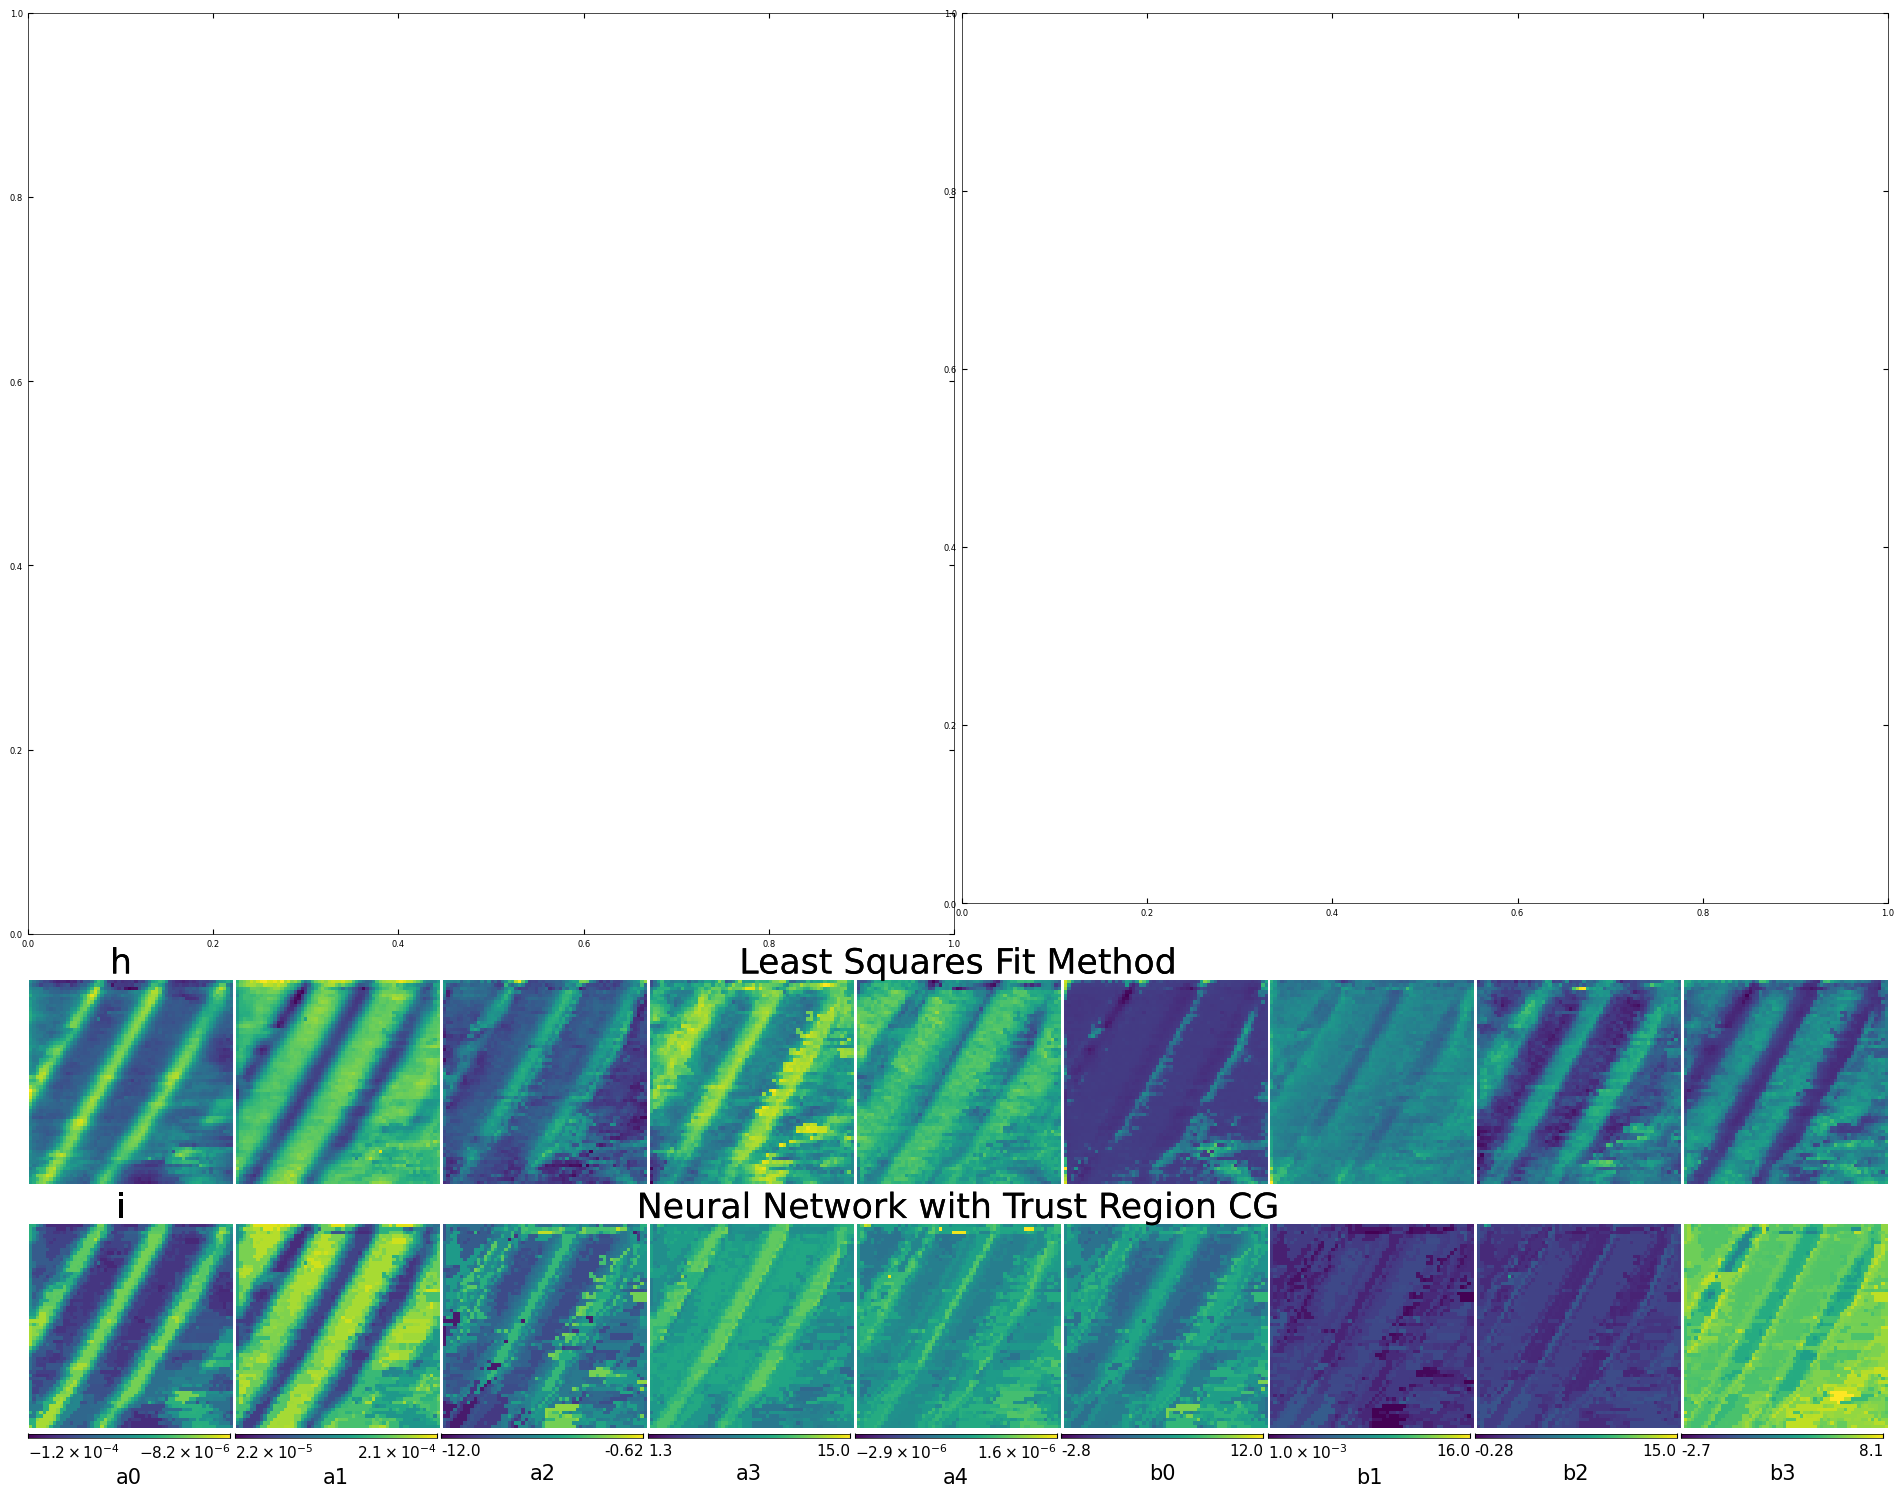

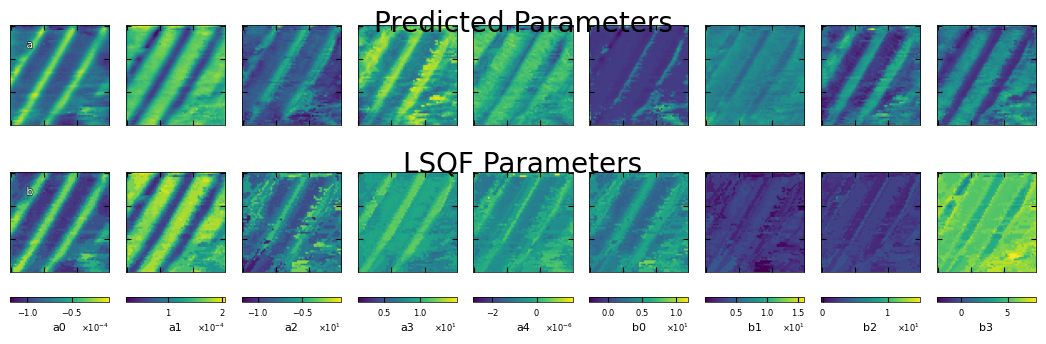

In [42]:
data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)
data = torch.atleast_3d(torch.tensor(data.reshape(-1, 96)))

data_names = ("LSQF", "NN")

fig = plt.figure(figsize=(24, 24))


# Define the GridSpec layout
gs = GridSpec(60, 40, figure=fig)


order = [['NN_fit_comp'],
         ['violin'],
         ['switching_maps']
        ]

subplot_specs = [(0, 30, 0, 20 ), # top left: NN fit comparisons 
                 (0, 29, 20, 40), # g
                 (30, 46, 0, 60), #bottom 
                 (30, 36, 0, 6), #bottom row 1 col 1
                 (30, 36, 8, 14), #bottom row 1 col 2
                 (30, 36, 16, 22), #bottom row 1 col 3
                 (30, 36, 24, 30), #bottom row 1 col 4
                 (30, 36, 32, 38), #bottom row 1 col 5
                 (30, 36, 40, 46), #bottom row 1 col 6
                 (30, 36, 48, 54), #bottom row 1 col 7
                 (30, 36, 56, 62), #bottom row 1 col 8
                 (30, 36, 64, 70), #bottom row 1 col 9
                 
                 (40, 46, 0, 6), #bottom row 2 col 1
                 (40, 46, 8, 14), #bottom row 2 col 2
                 (40, 46, 16, 22), #bottom row 2 col 3
                 (40, 46, 24, 30), #bottom row 2 col 4
                 (40, 46, 32, 38), #bottom row 2 col 5
                 (40, 46, 40, 46), #bottom row 2 col 6
                 (40, 46, 48, 54), #bottom row 2 col 7
                 (40, 46, 56, 62), #bottom row 2 col 8
                 (40, 46, 64, 70), #bottom row 2 col 9
                ]

clims=[
                    (0, 1.4e-4),  # amplitude
                    (1.31e6, 1.33e6),  # resonance frequency
                    (-230, -160),  # quality factor
                    (-np.pi, np.pi), # phase
                ] 


renderViolin = False
renderHysteresisMaps = True
renderBMWComp = False

colorbar_labels = [
                    'a0', 'a1', 'a2', 'a3', 'a4', 'b0', 'b1', 'b2', 'b3'
                ]

for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
    #if i < len(axes):
        try: 
            idx = order[i]
        except: 
            break
        ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])

        if idx[0] == 'violin':
            if renderViolin:
                BE_viz.violin_plot_comparison_hysteresis(model,
                                         torch.atleast_3d(torch.tensor(data.reshape(-1, 96))),
                                         filename=None,ax=ax) 

                # labels the figure and does some styling
                labelfigs(ax, string_add = 'g', loc ='tl',size=20, style="b", inset_fraction=(0.05,0.95))
                ax.set_ylabel("Scaled Hysteresis Results",fontsize=25)
                ax.set_xlabel("")
                
                ax.tick_params(axis='x',labelsize=20)
                ax.tick_params(axis='y',labelsize=20)

                # Get the legend associated with the plot
                legend = ax.get_legend()
                legend.set_title("")
                plt.setp(legend.get_texts(), fontsize=20) # Set the label size
        
        elif idx[0] == "switching_maps": 
            if renderHysteresisMaps:
               
                
                fig_hysteresis = BE_viz.hysteresis_maps(pred_params, cycle=0, filename=None);

                

                fig_scalar = FigDimConverter((1/2.5, 1/2.5))
                
                def fmt(x, pos):
                    a, b = '{:.1e}'.format(x).split('e')
                    b = int(b)
                    if abs(b) >2: 
                        return r'${} \times 10^{{{}}}$'.format(a, b)
                    
                    elif b==-1:
                        return format(float(a)*10**b,".2f")
                    else: 
                        return float(a)*10**b
                

                for row in range(2):
                    for col in range(9):
                        inset_ax = ax.inset_axes([-0.153+(col/8.99),1-(row+1.2)/2.4-row/12,1/2.4,1/2.4])
                        inset_ax.imshow(fig_hysteresis.get_axes()[col+9*row].get_images()[0].get_array().data,cmap = 'viridis',
                                         vmin = BE_viz.hysteresis_maps_clims[col][0], vmax = BE_viz.hysteresis_maps_clims[col][1])
                        inset_ax.axis("off")
                        
                        if row == 1:
                            bar_ax = []
                            
                            pos_inch = [(col/22.5), -0.008, 1/23, 1/300  ] #fills axes
                            bar_ax.append(ax.inset_axes(fig_scalar.to_relative(pos_inch)))

                            cbar = plt.colorbar(inset_ax.images[0],      
                                                cax=bar_ax[0], format=FuncFormatter(fmt),orientation = 'horizontal',
                                                ticks = [BE_viz.hysteresis_maps_clims[col][0], BE_viz.hysteresis_maps_clims[col][1]])
                            
                            cbar.ax.get_xticklabels()[0].set_horizontalalignment('left')
                            cbar.ax.get_xticklabels()[1].set_horizontalalignment('right')

                            cbar.ax.tick_params(labelsize = 11)

                            
                            cbar.set_label(colorbar_labels[col],size=15,loc='center')  # Add a label to the colorbar
                            
                            
                    if row == 0: 
                        labelfigs(ax,
                                string_add="Least Squares Fit Method",
                                loc='tl',size=25,inset_fraction = (0.05,0.5),style='b',
                                horizontalalignment = 'center',verticalalignment='center')
                        labelfigs(ax,
                                string_add="h",
                                loc='tl',size=25,inset_fraction = (0.05,0.05),style='b',
                                horizontalalignment = 'left',verticalalignment='center')
                    else:
                        labelfigs(ax,
                                string_add="Neural Network with Trust Region CG",
                                loc='tl',size=25,inset_fraction = (0.55,0.5),style='b',
                                horizontalalignment = 'center',verticalalignment='center')
                        labelfigs(ax,
                                string_add="i",
                                loc='tl',size=25,inset_fraction = (0.55,0.05),style='b',
                                horizontalalignment = 'left',verticalalignment='center')
                        
                ax.axis("off")         
        else:
            if renderBMWComp:                
                ax.axis("off")
                size=(1.25, 1.25)
                gaps=(1, 0.66)
                fig_BMW = BE_viz.hysteresis_comparison(data_names, nn_model=model, filename=None)

                
             #   list_ax.append(axs)
                axes_index = [5,4,3,2,1,0]

                
                for row in range(3):
                    for col in range(2):
                        inset_ax = ax.inset_axes([(col/2)-col*0.05,1-(row+1)/3.2,1/3.2,1/3.2])
                                                
                        #inset_ax.set_xlim([-16,16])
                        inset_ax.set_xticks([-16,0,16])
                        if row == 2: 
                            inset_ax.set_xlabel('Voltage(V)', fontsize=20)
                        else:
                            inset_ax.set_xlabel("")
                            inset_ax.xaxis.set_ticklabels([])
                        if row == 0: 
                            inset_ax.set_ylim([-1.7e-4,1.5e-4])
                            inset_ax.set_yticks(np.linspace(-1.5e-4,1.5e-4,5))
                            if col == 1:
                                inset_ax.set_yticklabels("")
                        elif row == 1: 
                            inset_ax.set_ylim([-1.5e-4,1.2e-4])
                            inset_ax.set_yticks(np.linspace(-1.5e-4,1e-4,6))
                            if col == 1:
                                inset_ax.set_yticklabels("")
                        else:
                            inset_ax.set_ylim([-6e-4, 1e-4])
                            if col == 1:
                                inset_ax.set_yticklabels("")
                        
                        
                            
                        for line in fig_BMW.get_axes()[axes_index[2*row+col]].get_lines():
                        #for line in ax_hyst_comp[2*row+col].get_lines():
                            label = line.get_label() if line.get_label() != '_nolegend_' else None
                            # Copying line properties like color, linestyle, marker, etc.
                            inset_ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color(),
                                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
                            
                        if col==0:   
                            set_sci_notation_label(
                                inset_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                                textsize = 10, offset_points = (0,30)
                            )
                        
                        
                        
                        inset_ax.tick_params(axis='x',labelsize=20)
                        inset_ax.tick_params(axis='y',labelsize=20)
                                    
                        plt.tight_layout()    
                        
                        
                        
                        if row == 0:
                        
                            labelfigs(inset_ax,
                                    string_add="Best",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                            
                        # get legend handles and their corresponding labels
                            handles, labels = inset_ax.get_legend_handles_labels()
                            

                            inset_ax.legend(handles,labels, loc=(0.4,0.65),fontsize = 15)
                            

                        elif row == 1:
                            labelfigs(inset_ax,
                                    string_add="Median",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                           
                        elif row == 2:
                            labelfigs(inset_ax,
                                    string_add="Worst",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment="center"
                                    )
                            ax.set_xticks([1.2,1.3,1.4])
                            
                        
                        labelfigs(inset_ax,
                            number=2*row+col,
                            loc ='tl',
                            size=15,
                            inset_fraction=(0.05,0.19),
                            style = 'b'
                            )


# Adjust the spacing between the plots as needed
plt.tight_layout()
                
# Show the layout
plt.show()

# BE_viz.printer.savefig(
#                 ax.figure, "Figure_4_test2"
#             )

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_example['Original Index'] = int(best_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worst_example['Original Index'] = int(worst_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

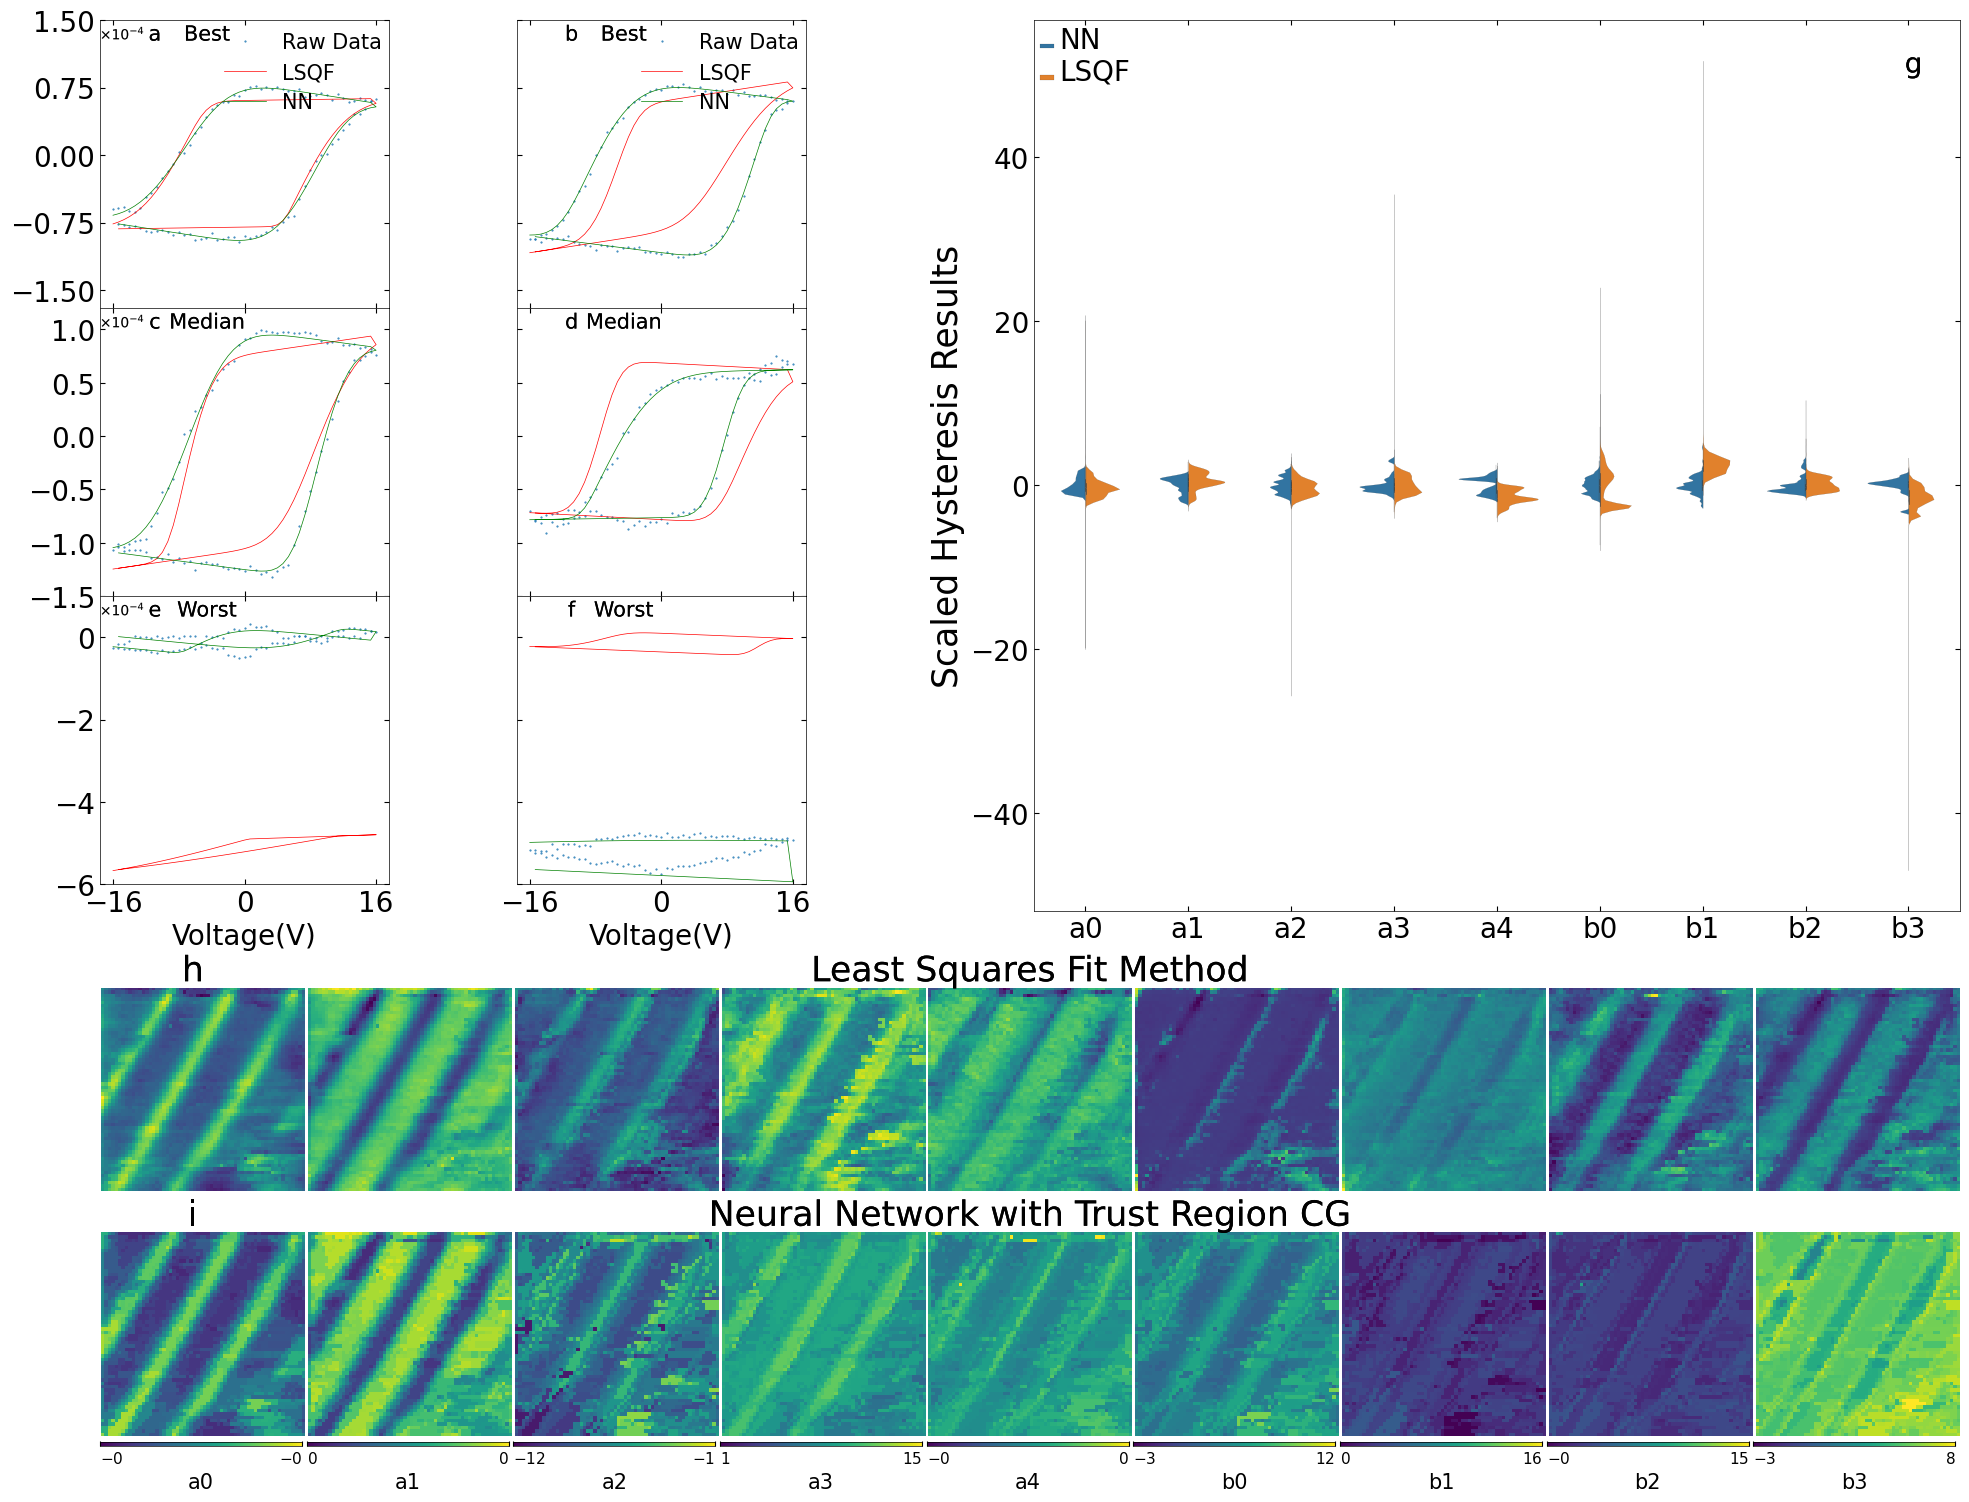

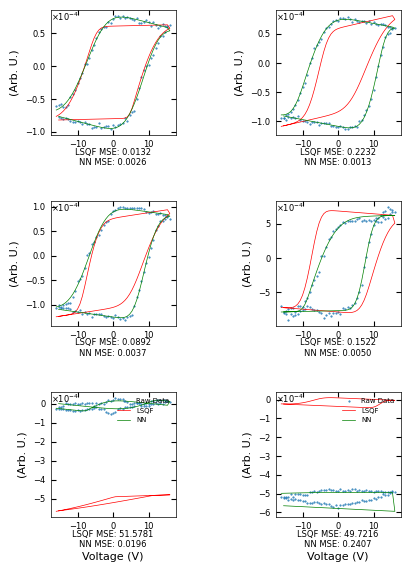

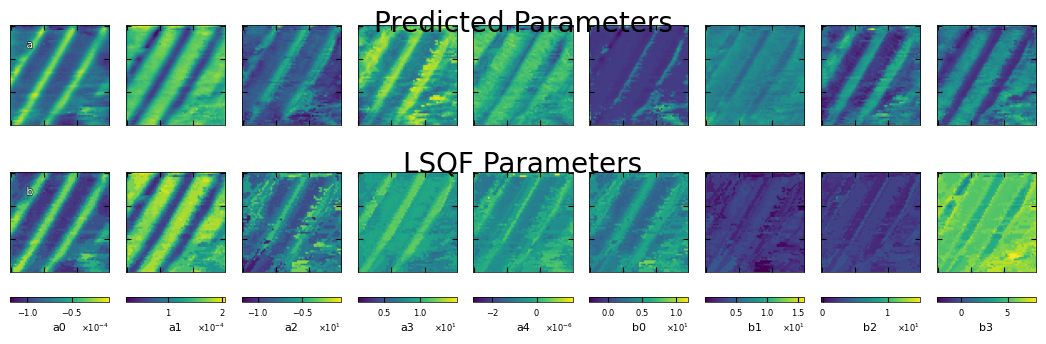

./Figures/Figure_4_func_2.png
./Figures/Figure_4_func_2.svg


In [73]:
BE_viz.plot_figure_4(model,pred_params,"Figure_4_func_2")

In [12]:
clims

NameError: name 'clims' is not defined

In [13]:
fig_scalar

NameError: name 'fig_scalar' is not defined

In [143]:
data

tensor([[[ 0.3089],
         [ 0.1603],
         [ 0.1098],
         ...,
         [-0.6803],
         [-0.6651],
         [-0.6515]],

        [[-0.7172],
         [-0.8387],
         [-0.7793],
         ...,
         [-0.6334],
         [-0.5495],
         [-0.5390]],

        [[ 0.2865],
         [ 0.3140],
         [ 0.3159],
         ...,
         [-0.8117],
         [-0.7958],
         [-0.7820]],

        ...,

        [[-0.9634],
         [-1.0170],
         [-0.9802],
         ...,
         [-0.8407],
         [-0.8662],
         [-0.9117]],

        [[-0.7887],
         [-0.7679],
         [-0.7291],
         ...,
         [-1.0134],
         [-0.9697],
         [-0.9828]],

        [[-0.9448],
         [-0.8975],
         [-0.9313],
         ...,
         [-0.9670],
         [-0.9519],
         [-0.9967]]], dtype=torch.float64)

In [117]:
order[2]

['switching_maps']

In [109]:
subplot_specs[0][2:4]

(0, 20)

In [111]:
gs[subplot_specs[0][0]:subplot_specs[0][1],subplot_specs[0][2]:subplot_specs[0][3]]

GridSpec(60, 40)[0:30, 0:20]

In [64]:
gs[subplot_specs[2][0]:subplot_specs[2][1],subplot_specs[2][2]:subplot_specs[2][3]]

GridSpec(60, 40)[30:46, 0:40]

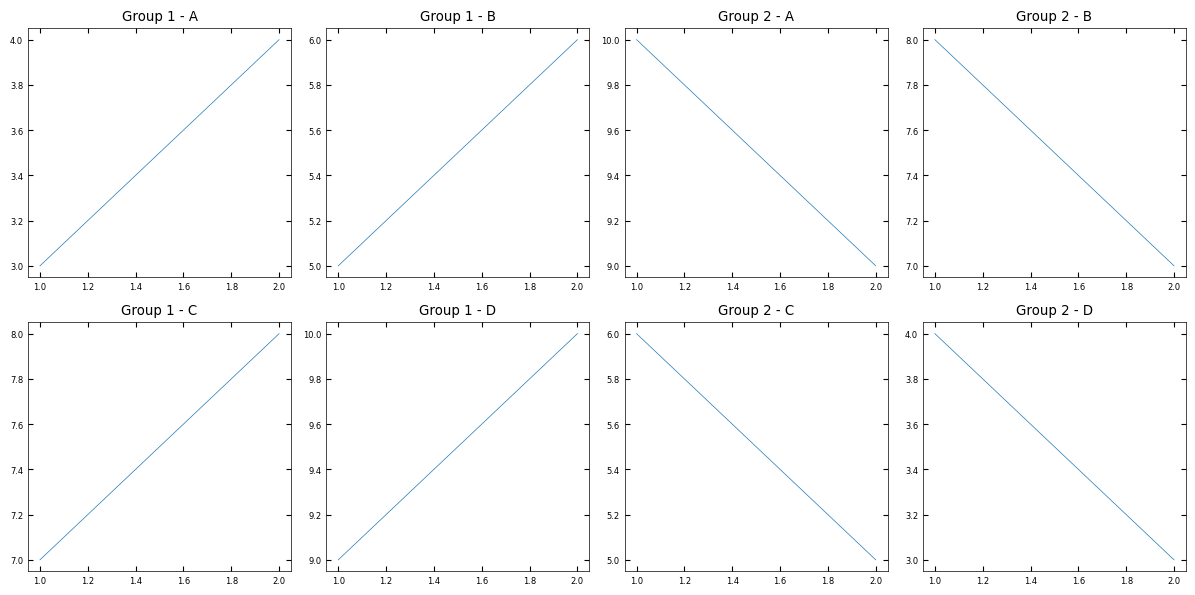

In [77]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_group(axs):
    axs[0][0].plot([1, 2], [3, 4])
    axs[0][0].set_title('Group 1 - A')
    axs[0][1].plot([1, 2], [5, 6])
    axs[0][1].set_title('Group 1 - B')
    axs[1][0].plot([1, 2], [7, 8])
    axs[1][0].set_title('Group 1 - C')
    axs[1][1].plot([1, 2], [9, 10])
    axs[1][1].set_title('Group 1 - D')

def plot_group2(axs):
    axs[0][0].plot([1, 2], [10, 9])
    axs[0][0].set_title('Group 2 - A')
    axs[0][1].plot([1, 2], [8, 7])
    axs[0][1].set_title('Group 2 - B')
    axs[1][0].plot([1, 2], [6, 5])
    axs[1][0].set_title('Group 2 - C')
    axs[1][1].plot([1, 2], [4, 3])
    axs[1][1].set_title('Group 2 - D')

def combine_all():
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 4, figure=fig)

    # Allocate left 2x2 block
    ax1_00 = fig.add_subplot(gs[0, 0])
    ax1_01 = fig.add_subplot(gs[0, 1])
    ax1_10 = fig.add_subplot(gs[1, 0])
    ax1_11 = fig.add_subplot(gs[1, 1])
    axs_group1 = [[ax1_00, ax1_01], [ax1_10, ax1_11]]
    plot_group(axs_group1)

    # Allocate right 2x2 block
    ax2_00 = fig.add_subplot(gs[0, 2])
    ax2_01 = fig.add_subplot(gs[0, 3])
    ax2_10 = fig.add_subplot(gs[1, 2])
    ax2_11 = fig.add_subplot(gs[1, 3])
    axs_group2 = [[ax2_00, ax2_01], [ax2_10, ax2_11]]
    plot_group2(axs_group2)

    fig.tight_layout()
    return fig

fig = combine_all()
fig.show()


<Axes: title={'center': 'Plot 1'}>

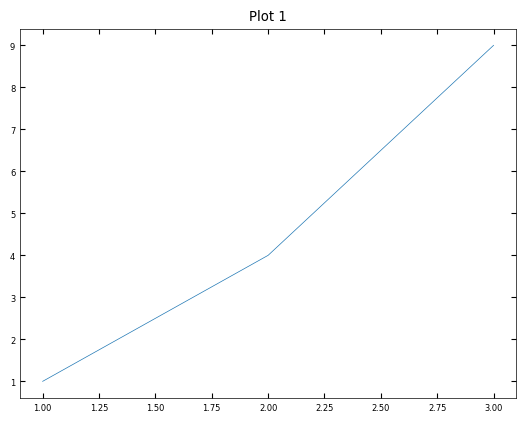

In [47]:
data1 = np.random.rand(100)
data2 = np.random.rand(100)
other_data = np.random.rand(100)


In [52]:
import matplotlib.pyplot as plt
import numpy as np

def regularPlot(subfig, data1, data2):
    """
    Builds a two-panel plot inside the provided subfigure.
    """
    axs = subfig.subplots(1, 2)
    axs[0].plot(data1)
    axs[0].set_title('Original Left')
    axs[0].set_xlabel('X Left')
    axs[0].set_ylabel('Y Left')

    axs[1].plot(data2)
    axs[1].set_title('Original Right')
    axs[1].set_xlabel('X Right')
    axs[1].set_ylabel('Y Right')

    subfig.suptitle('Original Inner Figure Title')

    return axs  # optionally return for further tweaks


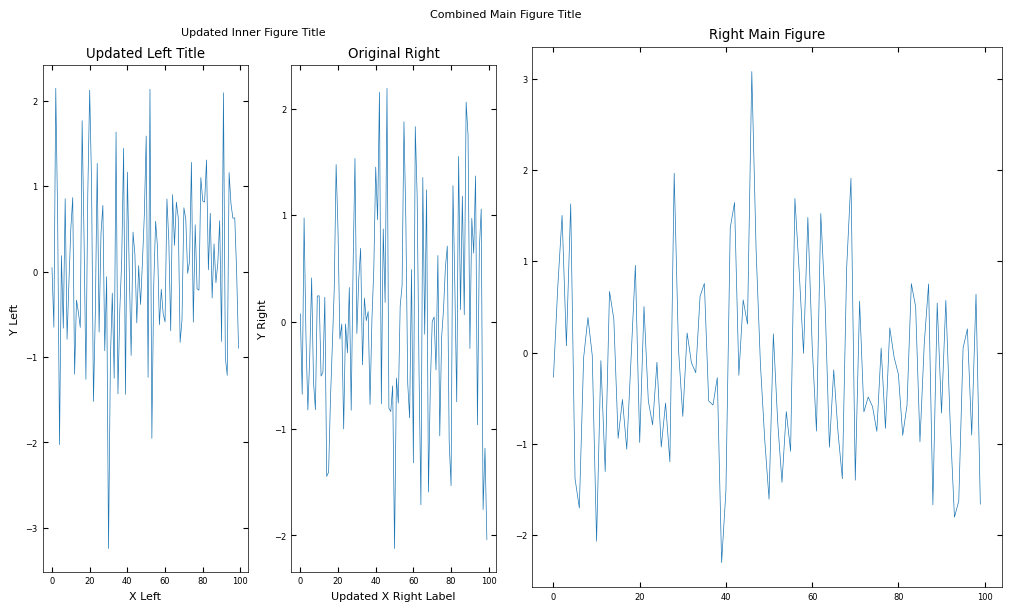

In [53]:
fig = plt.figure(constrained_layout=True, figsize=(10, 6))
subfigs = fig.subfigures(1, 2)

# Embed regularPlot into left subfigure
axs_inner = regularPlot(subfigs[0], np.random.randn(100), np.random.randn(100))

# Modify axis titles or labels AFTER embedding
axs_inner[0].set_title('Updated Left Title')
axs_inner[1].set_xlabel('Updated X Right Label')
subfigs[0].suptitle('Updated Inner Figure Title')

# Right side: some other plot
ax_right = subfigs[1].subplots()
ax_right.plot(np.random.randn(100))
ax_right.set_title('Right Main Figure')

fig.suptitle('Combined Main Figure Title')

plt.show()


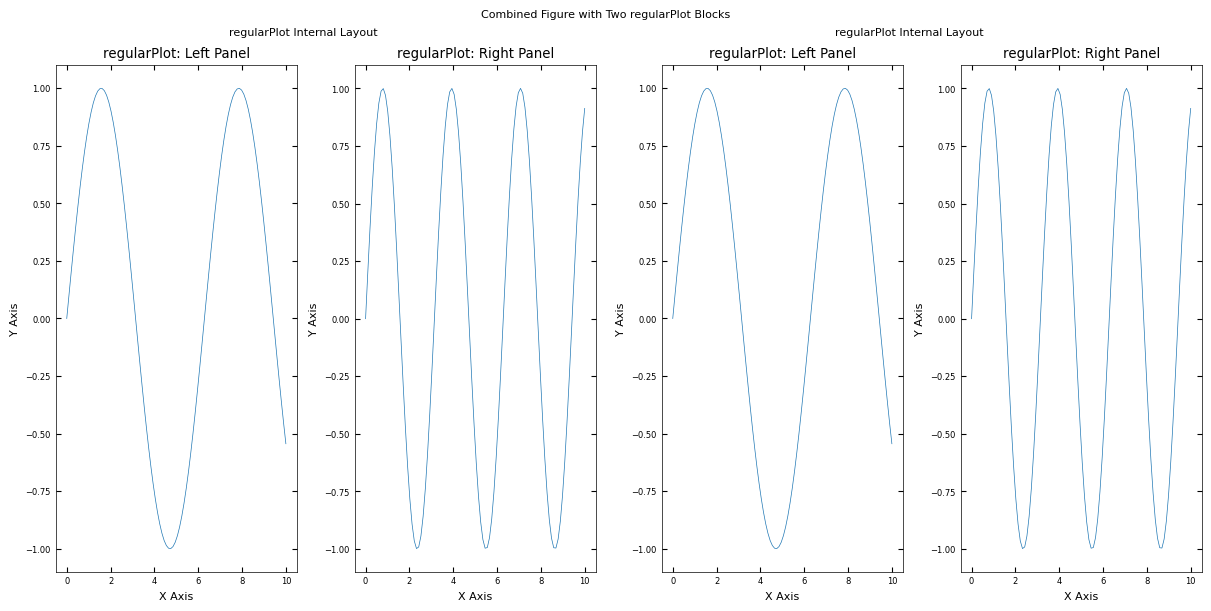

In [72]:
import matplotlib.pyplot as plt
import numpy as np

def regularPlot(x, parent_subfig=None):
    """
    Creates a 1x2 subplot layout.
    If parent_subfig is provided, plots inside it.
    Otherwise, creates its own figure and displays it.
    """
    if parent_subfig is None:
        # Standalone mode: create new figure directly
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        show_plot = True
    else:
        # Combined mode: use provided subfigure
        axs = parent_subfig.subplots(1, 2)
        show_plot = False

    y1 = np.sin(x)
    y2 = np.sin(2 * x)

    axs[0].plot(x, y1)
    axs[0].set_title('regularPlot: Left Panel')
    axs[0].set_xlabel('X Axis')
    axs[0].set_ylabel('Y Axis')

    axs[1].plot(x, y2)
    axs[1].set_title('regularPlot: Right Panel')
    axs[1].set_xlabel('X Axis')
    axs[1].set_ylabel('Y Axis')

    if parent_subfig is not None:
        parent_subfig.suptitle('regularPlot Internal Layout')
    else:
        fig.suptitle('regularPlot Standalone Layout')

    if show_plot:
        plt.show()

    return axs

# ─── Example 1: Standalone regularPlot ─────────────────────────────
x = np.linspace(0, 10, 100)
#regularPlot(x)

# ─── Example 2: Combined figure with two regularPlot blocks ────────
fig = plt.figure(constrained_layout=True, figsize=(12, 6))
outer_gs = fig.add_gridspec(1, 2)

# Left block
subfig_left = fig.add_subfigure(outer_gs[0])
regularPlot(x, parent_subfig=subfig_left)

# Right block
subfig_right = fig.add_subfigure(outer_gs[1])
regularPlot(x, parent_subfig=subfig_right)

fig.suptitle('Combined Figure with Two regularPlot Blocks')

plt.show()
